## Transport in the Drygalski Basin 

### Goal:

- Estimate the transport of HSSW in the Drygalski Basin between mooring DITD and DITD. What is the along trough transport of HSSW in the Drygalski Basin? How does this transport change seasonally? 

### Steps: 

- Rotate velocity into along and cross trough direction (will require figuring out the orientation of the Drygalski Trough)

- Make some assumptions about the width of HSSW current or trough and vertical extent of HSSW to use as area for multipying velocity by to get volume transport 

- Use salt and heat flux equations to get salt and heat transport 


### Data Needs: 

- TNBD 1100 m sensor velocity and CTD (need to average to same sampling frequency)

- DITD 1100 m sensor velocity and CTD (need to average to same sampling frequency)

- GEBCO bathymetry data 

- CTD data to help estimate what is the vertical extent of HSSW layer 


### Tasks to get started on: 

- load in TNBD and DITD data 

- Estimate the orientation of Drygalski Trough based on latitude and longitude of mooring data 

- Rotate currents to along and across trough 

- Make preliminary plots of along and across trough currents 

- Make some crude assumptions about width of HSSW current and vertical extent to estimate volume flow through the basin

In [1]:
# import packages 
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from scipy import signal, interpolate

In [2]:
def TS_template(ax1):
    """ 
    """
    # Create figure
    # fig = plt.figure(figsize=(10, 6),constrained_layout=True)
    # # Top left square
    # ax1 = plt.subplot(1,1,1)

    mint=-2.3
    maxt=-1.4
    mins=34.4
    maxs=36

    tempL=np.linspace(mint,maxt)
    salL=np.linspace(mins,maxs)
    Tg, Sg = np.meshgrid(tempL,salL)

    lon = 165
    lat = -75.0112
    p = 1093
    SA = gsw.SA_from_SP(Sg, p, lon, lat)
    CT = gsw.CT_from_pt(SA, Tg)
    # rho = gsw.rho(SA, Tg, 0)
    # sigma_theta = rho - 1000

    # CALCULATE DENSITY (METHOD 2)
    sigma_theta = gsw.sigma0(SA, CT)

    t_freezing1100 = gsw.t_freezing(gsw.SA_from_SP(salL, 0, lon, lat), p=0, saturation_fraction=0)
    plt.plot(salL, t_freezing1100, 'k--', label='Freezing Line at 0 dbar')

    cs = ax1.contour(Sg, Tg, sigma_theta, colors='k', zorder=1, alpha=0.7, levels=4)
    cl=plt.clabel(cs,fontsize=10,inline=True,manual=[(34.45,-2.2),(34.55,-2.05),(34.75,-1.75)])

In [3]:
import numpy as np
import pandas as pd
from scipy import signal, interpolate

# ── 1. GEOMETRIC TROUGH ORIENTATION ─────────────────────────────────────────
def trough_orientation_from_moorings(lon1, lat1, lon2, lat2):
    """
    Estimate trough axis orientation from two mooring positions.
    
    Assumes the two along-trough moorings define the trough axis.
    Uses a local flat-Earth approximation (valid over short distances
    typical of continental shelf troughs, ~10s of km).
    
    Parameters
    ----------
    lon1, lat1 : float
        Position of mooring 1 (decimal degrees)
    lon2, lat2 : float
        Position of mooring 2 (decimal degrees)
    
    Returns
    -------
    theta_deg : float
        Angle of trough axis CCW from East (degrees)
        This is the angle you rotate velocities BY to get along-trough
    bearing_deg : float
        Geographic bearing from mooring 1 to mooring 2 (degrees CW from North)
        Useful for sanity-checking against a map
    dx, dy : float
        Approximate along-East and along-North separation (km)
    """
    # Mean latitude for scaling (flat-Earth approximation)
    lat_mean = np.deg2rad((lat1 + lat2) / 2.0)
    
    R_earth = 6371.0  # km
    
    # Zonal and meridional separation
    dx = R_earth * np.cos(lat_mean) * np.deg2rad(lon2 - lon1)  # km, East+
    dy = R_earth * np.deg2rad(lat2 - lat1)                      # km, North+
    
    # Angle CCW from East — this is theta for the rotation matrix
    theta_deg = np.rad2deg(np.arctan2(dy, dx))
    
    # Geographic bearing (CW from North) — easier to sanity-check on a map
    bearing_deg = np.rad2deg(np.arctan2(dx, dy)) % 360
    
    dist_km = np.sqrt(dx**2 + dy**2)
    
    print(f"Mooring separation:  {dist_km:.1f} km")
    print(f"dx (East):           {dx:.1f} km")
    print(f"dy (North):          {dy:.1f} km")
    print(f"Trough axis angle from East (theta): {theta_deg:.1f}°")
    print(f"Geographic bearing M1→M2:            {bearing_deg:.1f}° (CW from North)")
    print(f"\nSanity check: positive v_along will point toward M2")
    
    return theta_deg, bearing_deg, dx, dy


# ── 2. VELOCITY ROTATION ─────────────────────────────────────────────────────
def rotate_velocities(u, v, theta_deg):
    """
    Rotate (u=East, v=North) to (along-trough, across-trough).
    
    Sign convention: positive v_along points from mooring 1 toward mooring 2.
    Flip sign afterward if that's up-trough rather than toward shelf break.
    
    Parameters
    ----------
    u, v      : array-like, eastward and northward velocity (m/s)
    theta_deg : float, trough axis angle CCW from East
    
    Returns
    -------
    v_along, v_across : rotated velocity components (m/s)
    """
    theta = np.deg2rad(theta_deg)
    v_along  =  u * np.cos(theta) - v * np.sin(theta) # u_prime, positive towards shelf break 
    v_across = u * np.sin(theta) + v * np.cos(theta) # v_prime, positive towards land (NW direction)
    return v_along, v_across


def principal_axis_angle(u, v):
    """
    Data-driven trough orientation from velocity variance ellipse.
    Use this to validate your geometric estimate — they should agree
    within ~10° for a well-channelized flow.
    """
    u_dm = u - np.nanmean(u)
    v_dm = v - np.nanmean(v)
    cov = np.cov(u_dm[~np.isnan(u_dm)], v_dm[~np.isnan(v_dm)])
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    major_axis = eigenvectors[:, np.argmax(eigenvalues)]
    theta_deg = np.rad2deg(np.arctan2(major_axis[1], major_axis[0]))
    return theta_deg


# ── 3. CROSS-SECTIONAL AREA ──────────────────────────────────────────────────
def estimate_cross_section(trough_widths_m, depth_bins_m, hssw_layer_top_m,
                            hssw_layer_bottom_m):
    """
    Estimate the cross-sectional area occupied by HSSW.
    
    For a single velocity measurement, this encodes your depth assumption.
    
    Parameters
    ----------
    trough_widths_m      : array of trough widths at each depth bin (m)
                           Get this from IBCSO/BedMachine bathymetry transect
    depth_bins_m         : array of depths corresponding to trough_widths_m (m)
    hssw_layer_top_m     : shallowest extent of HSSW layer (m, positive down)
                           Estimate from CTD casts or climatology
    hssw_layer_bottom_m  : deepest extent — usually trough floor at mooring loc
    
    Returns
    -------
    A_total    : total cross-sectional area of HSSW layer (m²)
    A_simple   : simple rectangular estimate W * H (m²) for comparison
    W_at_instr : trough width at instrument depth (m)
    """
    # Integrate trough width over the HSSW depth range
    mask = (depth_bins_m >= hssw_layer_top_m) & (depth_bins_m <= hssw_layer_bottom_m)
    
    if mask.sum() < 2:
        raise ValueError("Not enough depth bins within HSSW layer — "
                         "check your depth arrays")
    
    A_total = np.trapz(trough_widths_m[mask], depth_bins_m[mask])
    
    # Simple rectangular estimate (what you'd use with a single width value)
    H = hssw_layer_bottom_m - hssw_layer_top_m
    W_at_instr = float(np.interp(1100.0, depth_bins_m, trough_widths_m))
    A_simple = W_at_instr * H
    
    print(f"HSSW layer thickness:         {H:.0f} m")
    print(f"Trough width at 1100m:        {W_at_instr/1000:.1f} km")
    print(f"Area (integrated over width): {A_total/1e6:.2f} km²")
    print(f"Area (simple rectangle):      {A_simple/1e6:.2f} km²")
    print(f"Difference:                   {100*(A_total-A_simple)/A_simple:.1f}%")
    
    return A_total, A_simple, W_at_instr


def area_uncertainty(A_best, layer_thickness_uncertainty_m, W_at_instr):
    """
    Propagate layer thickness uncertainty into area and transport uncertainty.
    
    A rough ±1-sigma bound assuming your main uncertainty is in layer thickness.
    """
    A_low  = W_at_instr * (A_best / W_at_instr - layer_thickness_uncertainty_m)
    A_high = W_at_instr * (A_best / W_at_instr + layer_thickness_uncertainty_m)
    print(f"Area range: {A_low/1e6:.2f} – {A_high/1e6:.2f} km²")
    return A_low, A_high


# ── 4. FILTERING ─────────────────────────────────────────────────────────────
def lowpass_filter(data, cutoff_hours=36, dt_hours=1.0):
    """
    Zero-phase Butterworth low-pass filter.
    
    36h cutoff removes semidiurnal/diurnal tides and near-inertial motions.
    Inertial period at 70°S ~ 12.9h, so 36h is conservative.
    Consider 72h or 120h if you want to focus on synoptic/seasonal variability.
    """
    nyq = 0.5 / dt_hours          # Nyquist in cycles/hour
    fc  = 1.0 / cutoff_hours      # cutoff in cycles/hour
    b, a = signal.butter(4, fc / nyq, btype='low')
    # Handle NaNs by interpolating over gaps before filtering
    t = np.arange(len(data))
    finite = np.isfinite(data)
    data_filled = np.interp(t, t[finite], data[finite])
    filtered = signal.filtfilt(b, a, data_filled)
    filtered[~finite] = np.nan    # restore NaN gaps
    return filtered


# ── 5. HSSW IDENTIFICATION ───────────────────────────────────────────────────
def hssw_mask(salinity, temperature, S_threshold=34.6, T_threshold=-1.7):
    """
    Boolean mask for HSSW presence at the instrument.
    
    Adjust thresholds to your specific region — HSSW definitions vary
    between Ross Sea (~34.75), Weddell (~34.6), and other shelf troughs.
    Cross-reference against your CTD-based T/S diagram.
    """
    return (salinity >= S_threshold) & (temperature <= T_threshold)


# ── 6. TRANSPORT ─────────────────────────────────────────────────────────────
def compute_transports(v_along, salinity, temperature,
                       A, rho=1027.0, cp=3985.0, T_ref=-1.9):
    """
    Compute volume, salt, and heat transport time series.
    
    Parameters
    ----------
    v_along     : along-trough velocity (m/s), already low-pass filtered
    salinity    : practical salinity (g/kg)
    temperature : in-situ or potential temperature (°C)
    A           : cross-sectional area (m²)
    rho         : reference density (kg/m³) — ideally compute from T/S
    cp          : specific heat capacity (J/kg/K)
    T_ref       : reference temperature (°C) for heat transport
                  Use surface freezing point (~-1.9°C) for shelf work
    
    Returns
    -------
    dict of transport arrays, all as time series
    """
    Q   = v_along * A                              # m³/s
    F_S = rho * v_along * salinity * A             # kg/s
    F_H = rho * cp * v_along * (temperature - T_ref) * A  # W
    
    return {
        'Q_m3s':         Q,
        'Q_Sv':          Q / 1e6,
        'salt_flux_kgs': F_S,
        'heat_flux_W':   F_H,
        'heat_flux_GW':  F_H / 1e9,
    }


# ── 7. EDDY DECOMPOSITION ────────────────────────────────────────────────────
def eddy_flux_decomposition(v_along, scalar, A, rho=1027.0):
    """
    Decompose total flux into mean and eddy (turbulent) components.
    
    Total flux  = <v> * <S> * A  +  <v'S'> * A
    Mean flux   = v_bar * S_bar * A
    Eddy flux   = <v'S'> * A     (often non-negligible in troughs!)
    
    Works for salinity or temperature as the scalar.
    """
    v_bar = np.nanmean(v_along)
    s_bar = np.nanmean(scalar)
    
    v_prime = v_along - v_bar
    s_prime = scalar  - s_bar
    
    eddy_covariance = np.nanmean(v_prime * s_prime)
    
    mean_flux = rho * v_bar  * s_bar          * A
    eddy_flux = rho * eddy_covariance         * A
    total     = rho * np.nanmean(v_along * scalar) * A
    
    print(f"Mean flux:  {mean_flux:.2e}")
    print(f"Eddy flux:  {eddy_flux:.2e}  ({100*eddy_flux/total:.1f}% of total)")
    print(f"Total flux: {total:.2e}")
    
    return mean_flux, eddy_flux, total


# ── 8. MAIN WORKFLOW ─────────────────────────────────────────────────────────
def full_transport_pipeline(ds,
                             lon1, lat1, lon2, lat2,
                             trough_widths_m, depth_bins_m,
                             hssw_top_m, hssw_bottom_m,
                             S_thresh=34.6, T_thresh=-1.7,
                             T_ref=-1.9, dt_hours=1.0):
    """
    ds : xarray Dataset with variables u, v, temp, salinity (dim: time)
    lon1/lat1, lon2/lat2 : mooring positions (decimal degrees)
    trough_widths_m : trough width profile from bathymetry (m)
    depth_bins_m    : corresponding depths (m, positive down)
    hssw_top_m      : top of HSSW layer (m)
    hssw_bottom_m   : bottom of HSSW layer / trough floor (m)
    """
    # 1. Orientation
    print("=== TROUGH ORIENTATION ===")
    theta_geo, bearing, dx, dy = trough_orientation_from_moorings(
        lon1, lat1, lon2, lat2)
    theta_pca = principal_axis_angle(ds.u.values, ds.v.values)
    print(f"\nPCA angle cross-check: {theta_pca:.1f}°  "
          f"(difference: {abs(theta_geo - theta_pca):.1f}°)")
    print("If difference > 15°, examine whether flow is truly channelized\n")
    
    # Use geometric angle as primary; flag if PCA disagrees strongly
    theta = theta_geo
    
    # 2. Rotate
    v_along, v_across = rotate_velocities(ds.u.values, ds.v.values, theta)
    v_along_lp = lowpass_filter(v_along, cutoff_hours=36, dt_hours=dt_hours)
    
    # 3. Cross-sectional area
    print("=== CROSS-SECTIONAL AREA ===")
    A_integrated, A_simple, W_instr = estimate_cross_section(
        trough_widths_m, depth_bins_m, hssw_top_m, hssw_bottom_m)
    
    # 4. Transports (best estimate + uncertainty bounds)
    print("\n=== TRANSPORT (best estimate) ===")
    T_best = compute_transports(v_along_lp, ds.salinity.values,
                                 ds.temp.values, A_integrated)
    
    # 5. HSSW mask
    mask = hssw_mask(ds.salinity.values, ds.temp.values, S_thresh, T_thresh)
    print(f"\nHSSW present {100*mask.mean():.1f}% of record")
    
    # 6. Build output DataFrame
    df = pd.DataFrame({
        'v_along_raw':   v_along,
        'v_along_lp':    v_along_lp,
        'v_across':      v_across,
        'is_HSSW':       mask,
        **T_best
    }, index=ds.time.values)
    
    return df, theta_geo, A_integrated

### Load in data 

In [4]:
moorings = xr.open_datatree('/Users/mackenzie/Documents/Research/PhD/TNB_tools/preprocess/TNB_Moorings_DataTree.nc')

In [6]:
moorings['DITD/2018']

<xarray.DataTree '2018'>
Group: /DITD/2018
├── Group: /DITD/2018/vel
│   ├── Group: /DITD/2018/vel/top
│   │       Dimensions:  (time: 43002)
│   │       Coordinates:
│   │           z        int64 8B ...
│   │         * time     (time) datetime64[ns] 344kB 2018-03-10T16:10:00 ... 2019-01-03T0...
│   │           lat      float64 8B ...
│   │           lon      float64 8B ...
│   │       Data variables: (12/15)
│   │           dir      (time) float64 344kB ...
│   │           speed    (time) float64 344kB ...
│   │           temp     (time) float64 344kB ...
│   │           pres     (time) float64 344kB ...
│   │           hdgt     (time) float64 344kB ...
│   │           pitch    (time) float64 344kB ...
│   │           ...       ...
│   │           w        (time) float64 344kB ...
│   │           volt     (time) float64 344kB ...
│   │           amp1     (time) float64 344kB ...
│   │           amp2     (time) float64 344kB ...
│   │           amp3     (time) float64 344kB ...
│   │           depth    (time) float64 344kB ...
│   │       Attributes:
│   │           description:  Mooring DITD 1803 AQD
│   └── Group: /DITD/2018/vel/bot
│           Dimensions:  (time: 43002)
│           Coordinates:
│               z        int64 8B ...
│             * time     (time) datetime64[ns] 344kB 2018-03-10T16:10:00 ... 2019-01-03T0...
│               lat      float64 8B ...
│               lon      float64 8B ...
│           Data variables: (12/15)
│               dir      (time) float64 344kB ...
│               speed    (time) float64 344kB ...
│               temp     (time) float64 344kB ...
│               pres     (time) float64 344kB ...
│               hdgt     (time) float64 344kB ...
│               pitch    (time) float64 344kB ...
│               ...       ...
│               w        (time) float64 344kB ...
│               volt     (time) float64 344kB ...
│               amp1     (time) float64 344kB ...
│               amp2     (time) float64 344kB ...
│               amp3     (time) float64 344kB ...
│               depth    (time) float64 344kB ...
│           Attributes:
│               description:  Mooring DITD 1803 AQD
└── Group: /DITD/2018/ctd
    ├── Group: /DITD/2018/ctd/top
    │       Dimensions:  (time: 430023)
    │       Coordinates:
    │           z        int64 8B ...
    │         * time     (time) datetime64[ns] 3MB 2018-03-10T16:00:00 ... 2019-01-03T07:...
    │           lat      float64 8B ...
    │           lon      float64 8B ...
    │       Data variables:
    │           con      (time) float64 3MB ...
    │           temp     (time) float64 3MB ...
    │           pres     (time) float64 3MB ...
    │           depth    (time) float64 3MB ...
    │           sal      (time) float64 3MB ...
    │           sigma0   (time) float64 3MB ...
    │       Attributes:
    │           description:  Mooring DITD 1803 SBE37SM
    └── Group: /DITD/2018/ctd/bot
            Dimensions:  (time: 143284)
            Coordinates:
                z        int64 8B ...
              * time     (time) datetime64[ns] 1MB 2018-03-10T18:42:00 ... 2019-01-03T07:...
                lat      float64 8B ...
                lon      float64 8B ...
            Data variables:
                con      (time) float64 1MB ...
                temp     (time) float64 1MB ...
                pres     (time) float64 1MB ...
                depth    (time) float64 1MB ...
                sal      (time) float64 1MB ...
                sigma0   (time) float64 1MB ...
            Attributes:
                description:  Mooring DITD 1803 SBE37SM

In [7]:
# Load in data - MAC 
TNBD_ctd_top = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_ctd_top_999.nc')
TNBD_ctd_bot = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_ctd_bot_1093.nc')

TNBD_vel_top = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_vel_top_999.nc')
TNBD_vel_bot = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/tnbd_2018_vel_bot_1093.nc')

DITD_ctd_top = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/DITD_2018_ctd_top.nc')
DITD_ctd_bot = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/DITD_2018_ctd_bot.nc')

DITD_vel_top = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/vel_1100.nc')
DITD_vel_bot = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_tools/MastersThesis/vel_1200.nc')

In [11]:
# # load in data - DELL 
# TNBD_ctd_bot = xr.open_dataset("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2018_19 Araon Cruise (ANA09B) - NIWAMooringRetrieval/Data/TNBD/working/tnbd_2018_ctd_bot_1093.nc")
# TNBD_vel_bot = xr.open_dataset("//thepenguin/penguin2/Data/TNB/mooring/LDEO/2018_19 Araon Cruise (ANA09B) - NIWAMooringRetrieval/Data/TNBD/working/tnbd_2018_vel_bot_1093.nc")



# DITD_ctd_top = xr.open_dataset('/Users/mblan/Documents/TNB_Research/data/DITD_2018_2019/DITD_2018_ctd_top.nc')
# DITD_vel_top = xr.open_dataset('/Users/mblan/Documents/TNB_Research/data/DITD_2018_2019/vel_1100.nc')

In [12]:
# fix DITD time - should save this change permenantly later
DITD_vel_top['time'] = DITD_vel_top.time - pd.Timedelta(12,'h')

In [13]:
# rename variables in DITD velocity dataset 
DITD_vel_top = DITD_vel_top.rename({
    'east':'u',
    'north':'v',
    'up':'w',
    'pressure':'pres',
    'direction':'dir'
}).assign_coords({
    'z':1121,
    'lat':-75.28,
    'lon':164.1
})
# # rename variables in DITD velocity dataset 
# DITD_vel_bot = DITD_vel_bot.rename({
#     'east':'u',
#     'north':'v',
#     'up':'w',
#     'pressure':'pres',
#     'direction':'dir'
# }).assign_coords({
#     'z':1218,
#     'lat':-75.28,
#     'lon':164.1
# })

In [14]:
# # load in moorings datatree for mooring D data - DELL 
# moorings = xr.open_datatree('/Users/mblan/Documents/research/TNB_tools/preprocess/TNB_Moorings_DataTree.nc')

In [15]:
D_vel_bot = moorings['D/2017/vel/bot'].to_dataset().sel(time=slice('2018-03-01','2019-01-01'))
D_vel_mid = moorings['D/2017/vel/mid'].to_dataset().sel(time=slice('2018-03-01','2019-01-01'))
D_ctd_mid = moorings['D/2017/ctd/mid'].to_dataset().sel(time=slice('2018-03-01','2019-01-01'))

In [16]:
# D_ctd_mid = Calculate_TEOS10_vars(D_ctd_mid)

In [17]:
# convert velocity from m/s to cm/s 
# DITD_vel_top['u'] = DITD_vel_top.u * 100
# DITD_vel_top['v'] = DITD_vel_top.v * 100
# DITD_vel_top['speed'] = DITD_vel_top.speed * 100

# DITD_vel_bot['v'] = DITD_vel_bot.v * 100
# DITD_vel_bot['u'] = DITD_vel_bot.u * 100
# DITD_vel_bot['speed'] = DITD_vel_bot.speed * 100


### Identify trough orientation based on mooring positions

In [18]:
tnbd_lat = -75.0112
tnbd_lon = 165.5562

ditd_lat = -75.2751
ditd_lon = 164.0625

In [19]:
# using great circle distance 
tnbd_lat_rad = np.deg2rad(tnbd_lat)
tnbd_lon_rad = np.deg2rad(tnbd_lon)
ditd_lat_rad = np.deg2rad(ditd_lat)
ditd_lon_rad = np.deg2rad(ditd_lon)

In [20]:
delta_phi = ditd_lat_rad - tnbd_lat_rad
delta_y = ditd_lon_rad - tnbd_lon_rad

In [21]:
a = np.sin(delta_phi/2)**2 + np.cos(ditd_lat_rad)*np.cos(tnbd_lat_rad)*np.sin(delta_y/2)**2

In [22]:
c = 2*np.arctan2(np.sqrt(a),np.sqrt(1-a))

In [23]:
R = 6371 #km
d = R*c

In [24]:
d

np.float64(51.71544951194544)

In [25]:
theta = np.arctan2((np.sin(delta_y)*np.cos(tnbd_lat_rad)),(np.cos(ditd_lat_rad)*np.sin(tnbd_lat_rad)-np.sin(ditd_lat_rad)*np.cos(tnbd_lat_rad)*np.cos(delta_y)))

In [26]:
theta

np.float64(-0.9800845911230106)

In [27]:
np.rad2deg(theta)

np.float64(-56.15471063715346)

In [28]:
theta_deg, bearing_deg, dx, dy = trough_orientation_from_moorings(lon1=ditd_lon, lat1=ditd_lat, lon2=tnbd_lon, lat2=tnbd_lat)

Mooring separation:  51.7 km
dx (East):           42.6 km
dy (North):          29.3 km
Trough axis angle from East (theta): 34.6°
Geographic bearing M1→M2:            55.4° (CW from North)

Sanity check: positive v_along will point toward M2


In [29]:
theta_deg

np.float64(34.568716222087055)

In [30]:
90+np.rad2deg(theta)

np.float64(33.84528936284654)

In [31]:
principal_axis_angle(TNBD_vel_bot.u, TNBD_vel_bot.v)

np.float64(-74.95234100194489)

### Resample velocity and ctd data to be same sampling frequency

In [32]:
# convert TNBD velocity to m/s 
TNBD_vel_bot['v'] = TNBD_vel_bot.v / 100 
TNBD_vel_bot['u'] = TNBD_vel_bot.u / 100 

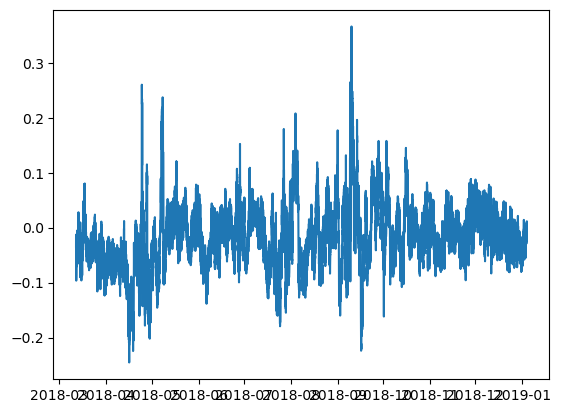

In [33]:
fig = plt.figure()
plt.plot(TNBD_vel_bot.time,TNBD_vel_bot.v)

In [34]:
# resample datasets to 15 min - this is coarsest sampling frequncy from TNBD current meter 
TNBD_ctd_15 = TNBD_ctd_bot.resample(time='15min').mean()
DITD_ctd_15 = DITD_ctd_top.resample(time='15min').mean()
DITD_vel_15 = DITD_vel_top.resample(time='15min').mean()

In [35]:
# 03-14 to 01-01
time_slice = slice('2018-03-14', '2019-01-01')
TNBD_ctd = TNBD_ctd_15.sel(time=time_slice)
DITD_ctd = DITD_ctd_15.sel(time=time_slice)
TNBD_vel = TNBD_vel_bot.sel(time=time_slice)
DITD_vel = DITD_vel_15.sel(time=time_slice)

In [36]:
len(TNBD_ctd.time), len(DITD_ctd.time), len(DITD_vel.time), len(TNBD_vel.time)

(28224, 28224, 28224, 28224)

### Rotate velocity and add to datasets 

In [37]:
DITD_v_along, DITD_v_across = rotate_velocities(DITD_vel.u, DITD_vel.v, theta_deg)
DITD_vel['u_prime'] = ('time',DITD_v_along.data)
DITD_vel['v_prime'] = ('time',DITD_v_across.data)

In [38]:
TNBD_v_along, TNBD_v_across = rotate_velocities(TNBD_vel.u, TNBD_vel.v, theta_deg)
TNBD_vel['u_prime'] = ('time',TNBD_v_along.data)
TNBD_vel['v_prime'] = ('time',TNBD_v_across.data)

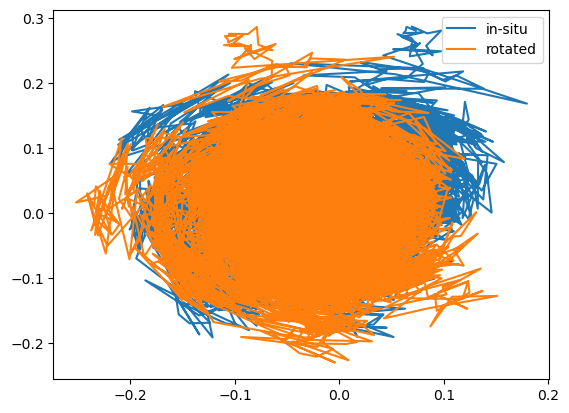

In [39]:
fig = plt.figure()
plt.plot(DITD_vel.u,DITD_vel.v,label='in-situ')
plt.plot(DITD_vel.u_prime,DITD_vel.v_prime,label='rotated')
plt.legend()

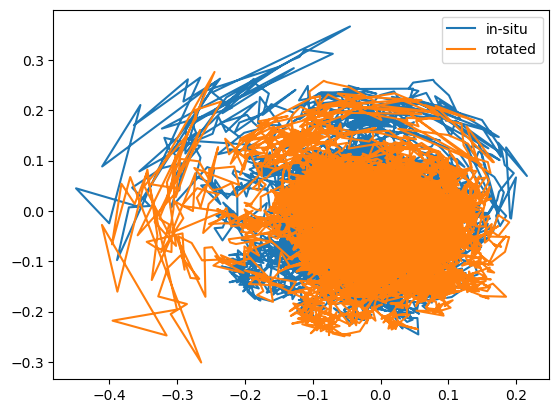

In [40]:
fig = plt.figure()
plt.plot(TNBD_vel.u,TNBD_vel.v,label='in-situ')
plt.plot(TNBD_vel.u_prime,TNBD_vel.v_prime,label='rotated')
plt.legend()

### TS Diagrams Colored by Velocity 

In [34]:
import gsw

In [35]:
import cmocean

In [36]:
%matplotlib widget

Text(0.5, 0, 'Absolute Salinity (g/kg)')

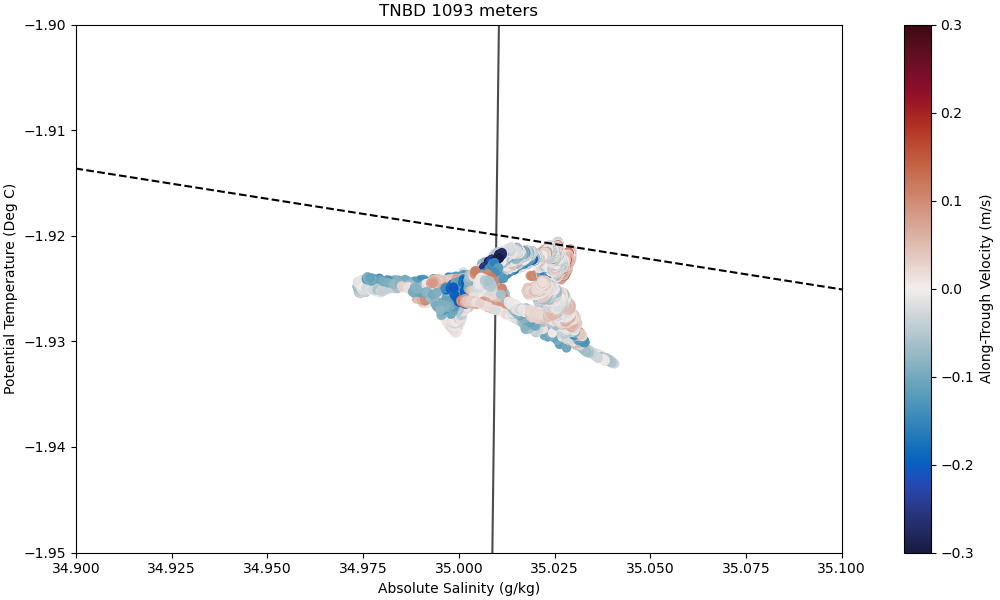

In [37]:
ds_ctd = TNBD_ctd
ds_vel = TNBD_vel
vel = 'u_prime'

fig = plt.figure(figsize=(10, 6),constrained_layout=True)
# Top left square
ax1 = plt.subplot(1,1,1)
TS_template(ax1)
plt.scatter(ds_ctd.abs_sal,ds_ctd.theta,c=ds_vel[vel],cmap=cmocean.cm.balance,vmin=-0.3,vmax=0.3)
plt.ylim(-1.950,-1.900)
plt.xlim(34.9,35.1)
plt.colorbar(label='Along-Trough Velocity (m/s)')
plt.title('TNBD 1093 meters')
plt.ylabel('Potential Temperature (Deg C)')
plt.xlabel('Absolute Salinity (g/kg)')

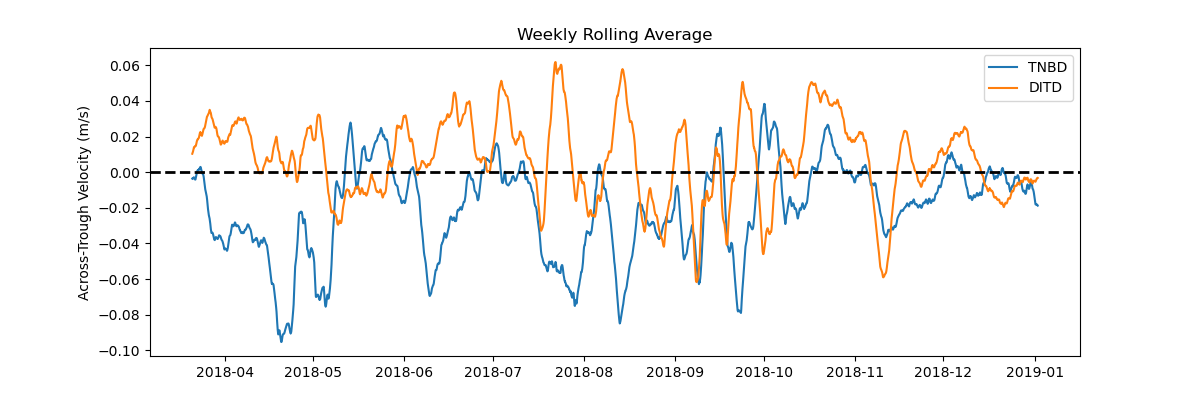

In [38]:
# time series plots of along and across trough velocity 
fig = plt.figure(figsize=(12,4))
plt.plot(TNBD_vel.rolling(time=672).mean().time,TNBD_vel.rolling(time=672).mean().v_prime,label='TNBD')
plt.plot(DITD_vel.rolling(time=672).mean().time,DITD_vel.rolling(time=672).mean().v_prime,label='DITD')
plt.axhline(y=0, color="k", linestyle="--", linewidth=2)
plt.title('Weekly Rolling Average')
plt.ylabel('Across-Trough Velocity (m/s)')
plt.legend()

Text(0.5, 1.0, 'TNBD Weekly Rolling Average')

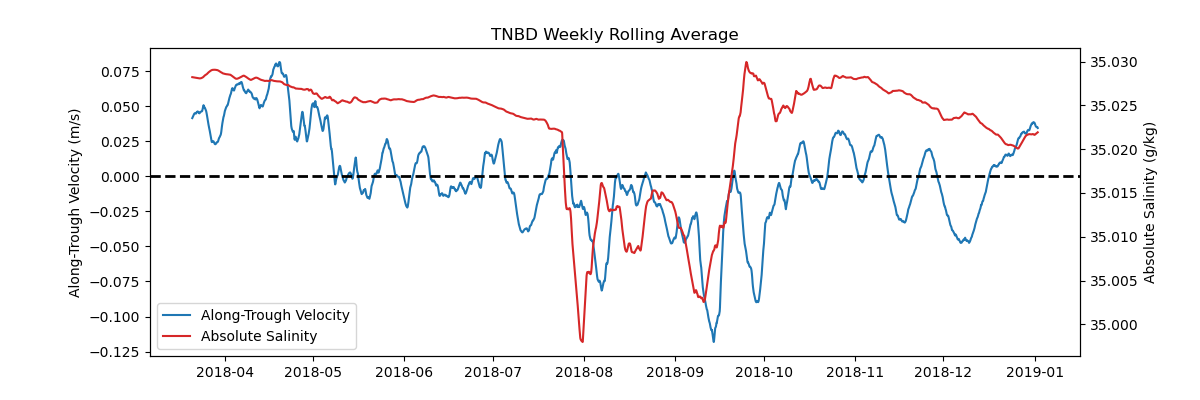

In [39]:
fig, ax = plt.subplots(figsize=(12,4))
plt.plot(TNBD_vel.rolling(time=672).mean().time,TNBD_vel.rolling(time=672).mean().u_prime,label='Along-Trough Velocity')
plt.axhline(y=0, color="k", linestyle="--", linewidth=2)
ax1 = ax.twinx()
ax1.plot(TNBD_ctd.rolling(time=672).mean().time,TNBD_ctd.rolling(time=672).mean().abs_sal,label='Absolute Salinity',color='tab:red')
# 4. Gather handles and labels from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()

# 5. Combine lists and generate a single legend on either axis
ax1.legend(lines1 + lines2, labels1 + labels2)
ax1.set_ylabel('Absolute Salinity (g/kg)')
# ax1.set_ylabel('Potential Temperature [Deg C]')
ax.set_ylabel('Along-Trough Velocity (m/s)')
plt.title('TNBD Weekly Rolling Average')

Text(0.5, 1.0, 'DITD Weekly Rolling Average')

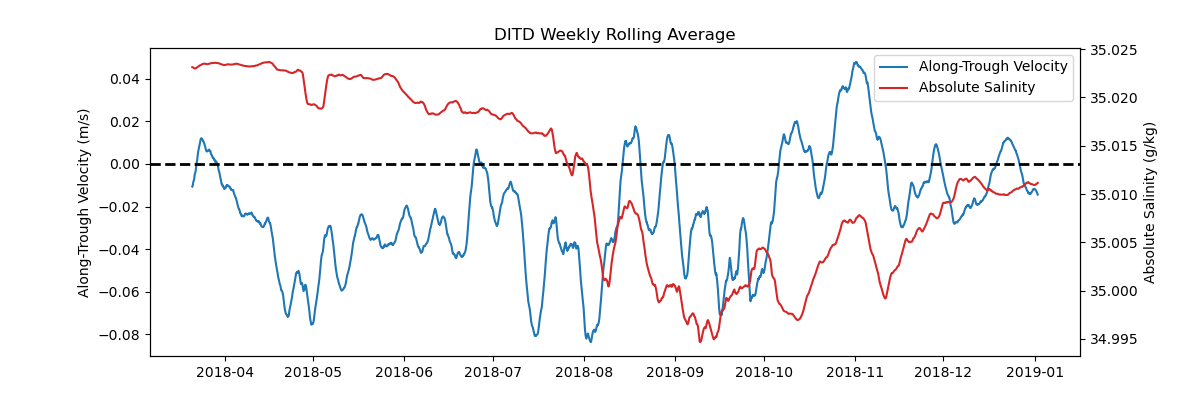

In [40]:
fig, ax = plt.subplots(figsize=(12,4))
plt.plot(DITD_vel.rolling(time=672).mean().time,DITD_vel.rolling(time=672).mean().u_prime,label='Along-Trough Velocity')
plt.axhline(y=0, color="k", linestyle="--", linewidth=2)
ax1 = ax.twinx()
ax1.plot(DITD_ctd.rolling(time=672).mean().time,DITD_ctd.rolling(time=672).mean().abs_sal,label='Absolute Salinity',color='tab:red')
# 4. Gather handles and labels from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()

# 5. Combine lists and generate a single legend on either axis
ax1.legend(lines1 + lines2, labels1 + labels2)
ax1.set_ylabel('Absolute Salinity (g/kg)')
# ax1.set_ylabel('Potential Temperature [Deg C]')
ax.set_ylabel('Along-Trough Velocity (m/s)')
plt.title('DITD Weekly Rolling Average')

Text(0.5, 1.0, 'TNBD')

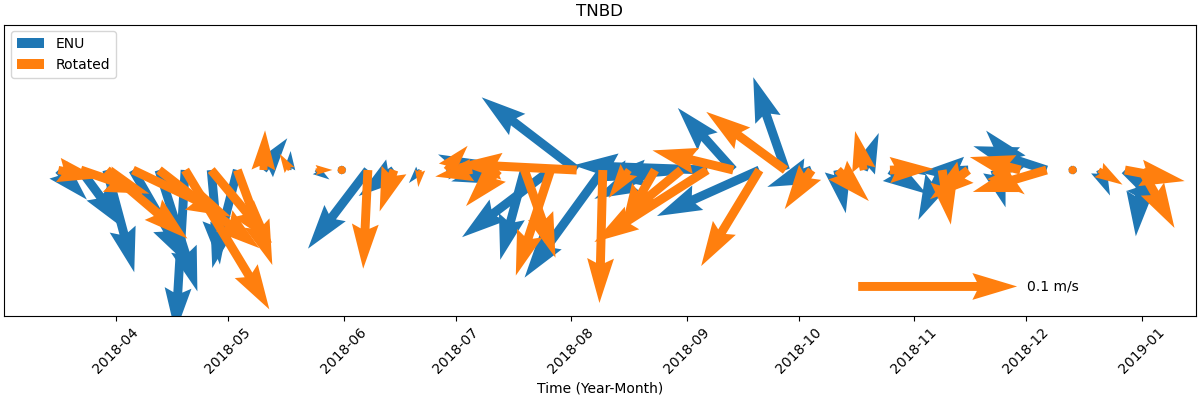

In [41]:
fig = plt.figure(figsize=(12,4),constrained_layout=True)
resample = 'W'
q = plt.quiver(
    TNBD_vel.time.resample(time=resample).mean().values,np.zeros(len(TNBD_vel.time.resample(time=resample).mean())),
    TNBD_vel.u.resample(time=resample).mean(),
    TNBD_vel.v.resample(time=resample).mean(), scale=0.75, units='width',color='tab:blue',label='ENU'
)
q = plt.quiver(
    TNBD_vel.time.resample(time=resample).mean().values,np.zeros(len(TNBD_vel.time.resample(time=resample).mean())),
    TNBD_vel.u_prime.resample(time=resample).mean(),
    TNBD_vel.v_prime.resample(time=resample).mean(), scale=0.75,units='width',color='tab:orange',label='Rotated'
)
plt.quiverkey(q, X=0.85, Y=0.1, U=0.1, label='0.1 m/s', labelpos='E')
# plt.ylabel('Speed (m/s)')
plt.yticks([])
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.xlabel('Time (Year-Month)')
plt.title('TNBD')
# ax5.text(0.95, 0.89, 'E.', transform=ax5.transAxes, fontsize=10, fontweight='bold')

Text(0, 0.5, 'Speed (m/s)')

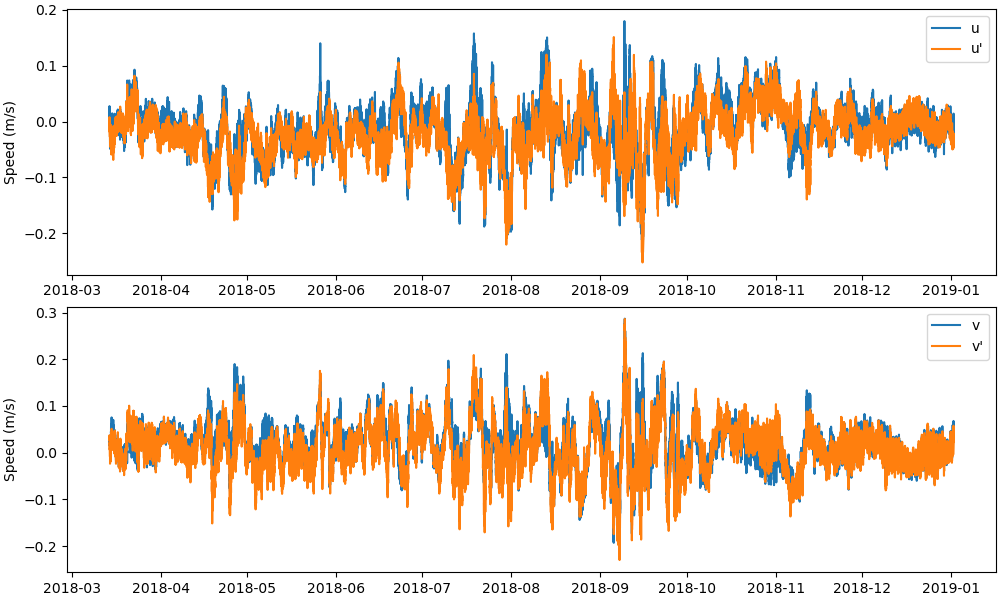

In [42]:
fig, ax = plt.subplots(nrows=2,ncols=1,constrained_layout=True,figsize=(10,6))
ax[0].plot(DITD_vel.time,DITD_vel.u,label='u')
ax[0].plot(DITD_vel.time,DITD_vel.u_prime,label="u'")
ax[0].legend()
ax[0].set_ylabel('Speed (m/s)')

ax[1].plot(DITD_vel.time,DITD_vel.v,label='v')
ax[1].plot(DITD_vel.time,DITD_vel.v_prime,label="v'")
ax[1].legend()
ax[1].set_ylabel('Speed (m/s)')

Text(0.5, 1.0, 'DITD Weekly Averaged Velocity Rotation (~35 degrees CCW)')

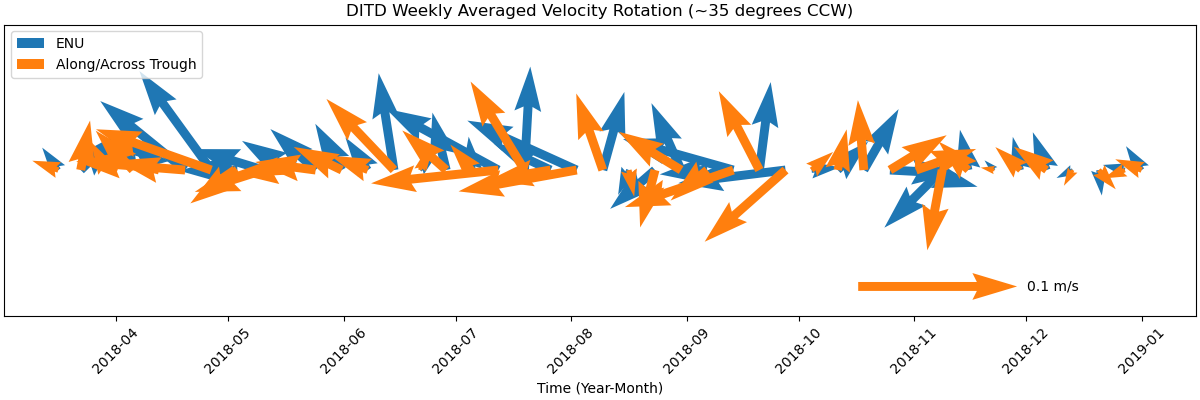

In [43]:
fig = plt.figure(figsize=(12,4),constrained_layout=True)
resample = 'W'
q = plt.quiver(
    DITD_vel.time.resample(time=resample).mean().values,np.zeros(len(DITD_vel.time.resample(time=resample).mean())),
    DITD_vel.u.resample(time=resample).mean(),
    DITD_vel.v.resample(time=resample).mean(), scale=0.75, units='width',color='tab:blue',label='ENU'
)
q = plt.quiver(
    DITD_vel.time.resample(time=resample).mean().values,np.zeros(len(DITD_vel.time.resample(time=resample).mean())),
    DITD_vel.u_prime.resample(time=resample).mean(),
    DITD_vel.v_prime.resample(time=resample).mean(), scale=0.75,units='width',color='tab:orange',label='Along/Across Trough'
)
plt.quiverkey(q, X=0.85, Y=0.1, U=0.1, label='0.1 m/s', labelpos='E')
# plt.ylabel('Speed (m/s)')
plt.yticks([])
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.xlabel('Time (Year-Month)')
plt.title('DITD Weekly Averaged Velocity Rotation (~35 degrees CCW)')
# ax5.text(0.95, 0.89, 'E.', transform=ax5.transAxes, fontsize=10, fontweight='bold')

### Estimate vertical extent of HSSW layer using CTD data 

In [44]:
# load in CTD data 
palmer = xr.open_dataset('Palmer_ctd_DrygalskiBasin.nc')
pipers = xr.open_dataset('PIPERS_ctd_DrygalskiBasin.nc')

In [79]:
pipers.time.values

array(['2017-05-07T15:28:47.999999744', '2017-05-06T02:29:45.600000000',
       '2017-05-09T07:27:50.399999744', '2017-05-09T13:30:43.200000000',
       '2017-05-06T13:07:40.800000256', '2017-05-06T17:58:33.600000000',
       '2017-05-02T11:32:38.400000256', '2017-05-09T18:24:28.800000000',
       '2017-05-04T23:00:57.600000000', '2017-05-10T05:16:48.000000000'],
      dtype='datetime64[ns]')

In [82]:
palmer.Date.values

array([['2018-01-30', '2018-01-30', '2018-01-30', ..., '', '', ''],
       ['2018-02-07', '2018-02-07', '2018-02-07', ..., '', '', ''],
       ['2018-01-30', '2018-01-30', '2018-01-30', ..., '', '', ''],
       ...,
       ['2018-01-11', '2018-01-11', '2018-01-11', ..., '', '', ''],
       ['2018-01-27', '2018-01-27', '2018-01-27', ..., '', '', ''],
       ['2018-02-08', '2018-02-08', '2018-02-08', ..., '', '', '']],
      shape=(13, 1522), dtype='<U10')

Text(0.5, 1.0, 'PIPERS CTD Data')

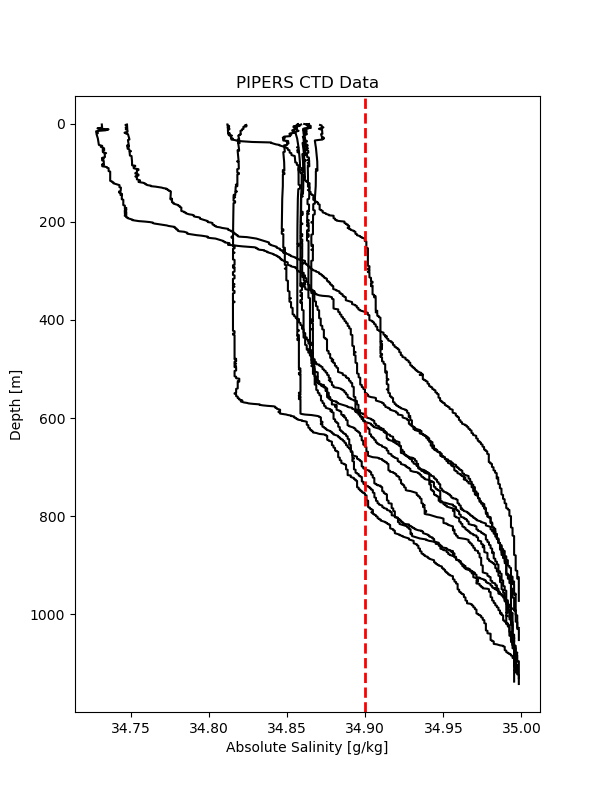

In [71]:
fig = plt.figure(figsize=(6,8))
for st in range(len(pipers.station)):
    plt.plot(pipers.isel(station=st).Absolute_Salinity,pipers.isel(station=st).depth,color='k')
plt.gca().invert_yaxis()
# Single vertical line (full height)
plt.axvline(x=34.9, color='r', linestyle='--', linewidth=2, label='x=2')
plt.ylabel('Depth [m]')
plt.xlabel('Absolute Salinity [g/kg]')
plt.title('PIPERS CTD Data')


(33.6, 35.25)

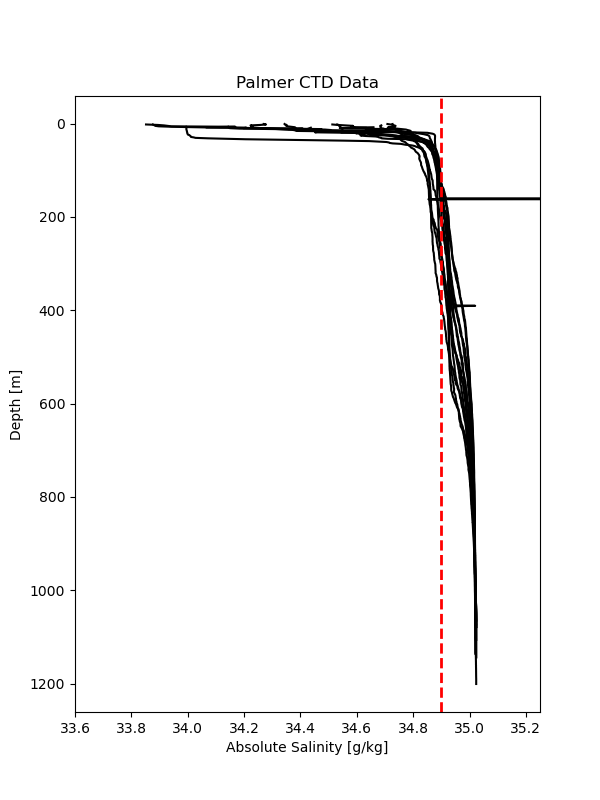

In [77]:
fig = plt.figure(figsize=(6,8))
for st in range(len(palmer.station)):
    plt.plot(palmer.isel(station=st).Absolute_Salinity,palmer.isel(station=st).Depth,color='k')
plt.gca().invert_yaxis()
# Single vertical line (full height)
plt.axvline(x=34.9, color='r', linestyle='--', linewidth=2, label='x=2')
plt.ylabel('Depth [m]')
plt.xlabel('Absolute Salinity [g/kg]')
plt.title('Palmer CTD Data')
plt.xlim(33.6,35.25)

In [59]:
def hssw_thickness_1(ds, salinity_var="SA", depth_var="depth", threshold=34.9):
    """
    Compute HSSW layer thickness for each station in a CTD dataset.

    HSSW top boundary = shallowest depth below which ALL samples
    remain above the salinity threshold (i.e. the layer is contiguous
    down to the bottom of the cast). This is more robust to noisy
    spikes near the boundary than a simple "first exceedance" approach.

    Thickness = max profile depth - HSSW top depth

    Returns a DataArray of thickness values (one per station), with NaN
    for stations that never reach the HSSW threshold, or where the
    bottom-most sample itself is below threshold (no HSSW at depth).
    """
    thicknesses = []
    station_ids = []

    for stn in ds["station"].values:
        profile = ds.sel(station=stn)

        depth = profile[depth_var].values
        salt = profile[salinity_var].values

        # drop NaNs
        valid = np.isfinite(depth) & np.isfinite(salt)
        depth = depth[valid]
        salt = salt[valid]

        if depth.size == 0:
            thicknesses.append(np.nan)
            station_ids.append(stn)
            continue

        # sort by depth ascending (shallow -> deep), in case sample
        # order doesn't already correspond to depth order
        order = np.argsort(depth)
        depth = depth[order]
        salt = salt[order]

        max_depth = depth[-1]

        # working from the bottom (deepest) sample upward, find the
        # shallowest index from which every sample to the bottom is
        # above threshold
        above = salt > threshold

        if not above[-1]:
            # bottom of cast isn't even HSSW -> no HSSW layer at depth
            thickness = np.nan
        else:
            # walk upward from the bottom while still above threshold
            idx = len(above) - 1
            while idx > 0 and above[idx - 1]:
                idx -= 1
            hssw_top_depth = depth[idx]
            thickness = max_depth - hssw_top_depth

        thicknesses.append(thickness)
        station_ids.append(stn)

    return xr.DataArray(
        thicknesses,
        coords={"station": station_ids},
        dims="station",
        name="HSSW_thickness"
    )

In [60]:
thickness_pipers_1 = hssw_thickness_1(pipers,salinity_var='Absolute_Salinity', depth_var='depth')
thickness_palmer_1 = hssw_thickness_1(palmer,salinity_var='Absolute_Salinity',depth_var='Depth')

In [61]:
thickness_palmer_1

<xarray.DataArray 'HSSW_thickness' (station: 13)> Size: 104B
array([ 724.986,  866.356,  743.398,  922.944,  730.985,  976.767,
       1015.161,  916.586,  939.192,  915.593,  934.44 ,  885.953,
        769.663])
Coordinates:
  * station  (station) int64 104B 44 59 43 25 42 38 26 22 24 23 27 36 60

In [78]:
thickness_pipers_1.mean()

<xarray.DataArray 'HSSW_thickness' ()> Size: 8B
array(494.726)

In [83]:
thickness_pipers_1.median()

<xarray.DataArray 'HSSW_thickness' ()> Size: 8B
array(486.86)

In [65]:
all_thickness = xr.concat([thickness_pipers_1, thickness_palmer_1], dim="station")

mean_thickness = all_thickness.mean(skipna=True)
n_with_hssw = all_thickness.notnull().sum().item()
n_total = all_thickness.size

print(f"Mean HSSW thickness: {mean_thickness.values:.1f} m")
print(f"HSSW present in {n_with_hssw}/{n_total} profiles")

Mean HSSW thickness: 708.2 m
HSSW present in 23/23 profiles


### Calculate salinity and temperature anomalies 

In [97]:
# TNBD sal and T anomalies 
TNBD_ctd['abs_sal_anom'] = TNBD_ctd.abs_sal - TNBD_ctd.abs_sal.mean()
DITD_ctd['abs_sal_anom'] = DITD_ctd.abs_sal - DITD_ctd.abs_sal.mean()

TNBD_ctd['theta_anom'] = TNBD_ctd.theta - TNBD_ctd.theta.mean()
DITD_ctd['theta_anom'] = DITD_ctd.theta - DITD_ctd.theta.mean()



(-0.025, 0.025)

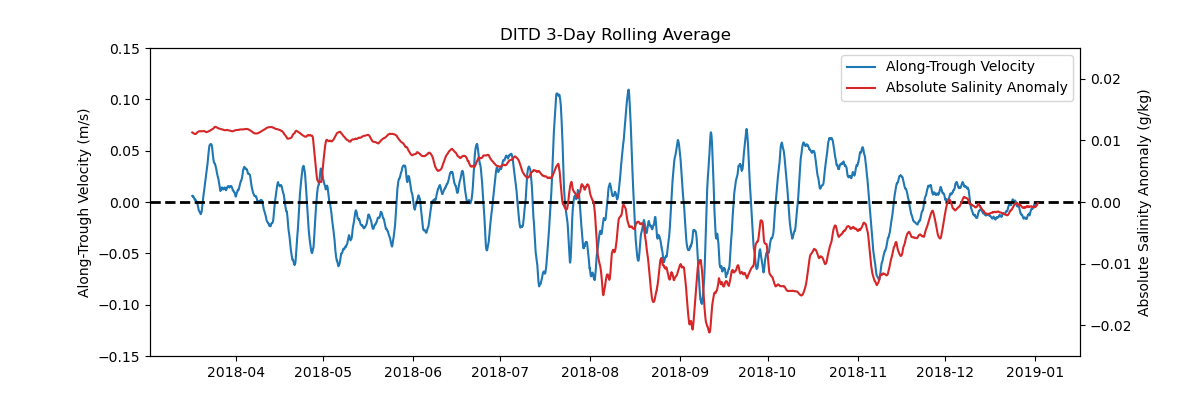

In [100]:
fig, ax = plt.subplots(figsize=(12,4))
plt.plot(DITD_vel.rolling(time=288).mean().time,DITD_vel.rolling(time=288).mean().v_along,label='Along-Trough Velocity')
plt.axhline(y=0, color="k", linestyle="--", linewidth=2)
ax1 = ax.twinx()
ax1.plot(DITD_ctd.rolling(time=288).mean().time,DITD_ctd.rolling(time=288).mean().abs_sal_anom,label='Absolute Salinity Anomaly',color='tab:red')
# 4. Gather handles and labels from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()

# 5. Combine lists and generate a single legend on either axis
ax1.legend(lines1 + lines2, labels1 + labels2)
ax1.set_ylabel('Absolute Salinity Anomaly (g/kg)')
# ax1.set_ylabel('Potential Temperature [Deg C]')
ax.set_ylabel('Along-Trough Velocity (m/s)')
plt.title('DITD 3-Day Rolling Average')
ax.set_ylim(-0.15,0.15)
ax1.set_ylim(-0.025,0.025)

(-0.035, 0.035)

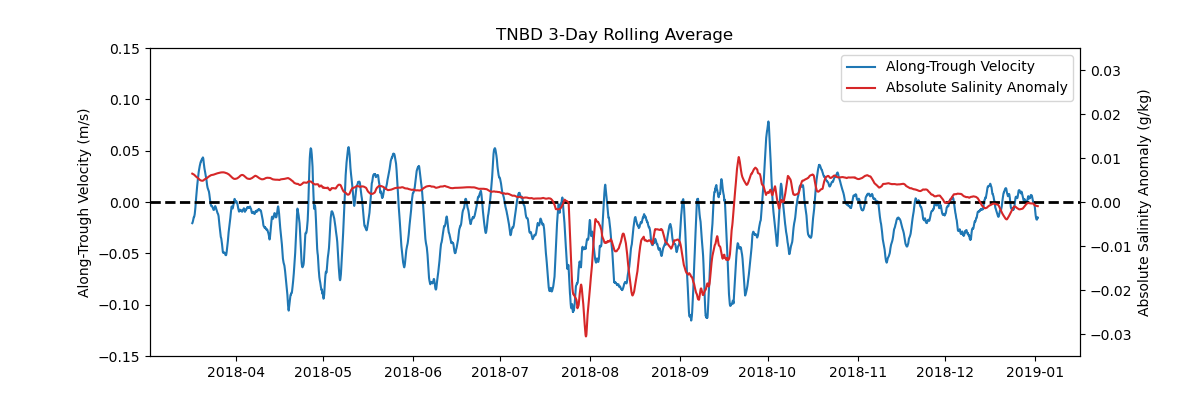

In [105]:
fig, ax = plt.subplots(figsize=(12,4))
plt.plot(TNBD_vel.rolling(time=288).mean().time,TNBD_vel.rolling(time=288).mean().v_along,label='Along-Trough Velocity')
plt.axhline(y=0, color="k", linestyle="--", linewidth=2)
ax1 = ax.twinx()
ax1.plot(TNBD_ctd.rolling(time=288).mean().time,TNBD_ctd.rolling(time=288).mean().abs_sal_anom,label='Absolute Salinity Anomaly',color='tab:red')
# 4. Gather handles and labels from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()

# 5. Combine lists and generate a single legend on either axis
ax1.legend(lines1 + lines2, labels1 + labels2)
ax1.set_ylabel('Absolute Salinity Anomaly (g/kg)')
# ax1.set_ylabel('Potential Temperature [Deg C]')
ax.set_ylabel('Along-Trough Velocity (m/s)')
plt.title('TNBD 3-Day Rolling Average')
ax.set_ylim(-0.15,0.15)
ax1.set_ylim(-0.035,0.035)

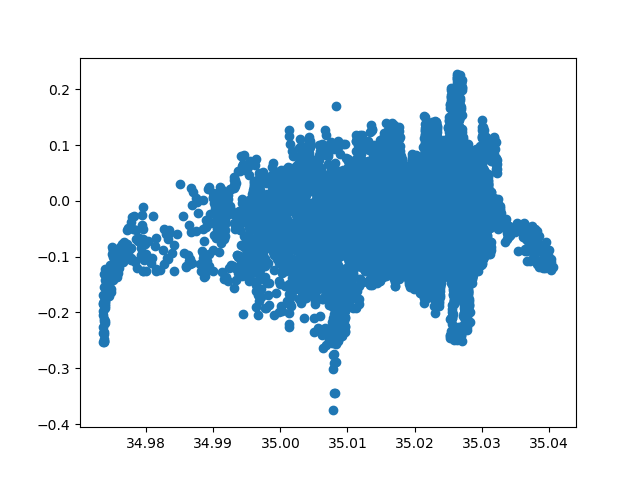

In [125]:
fig = plt.figure()
plt.scatter(TNBD_ctd.abs_sal,TNBD_vel.v_along)

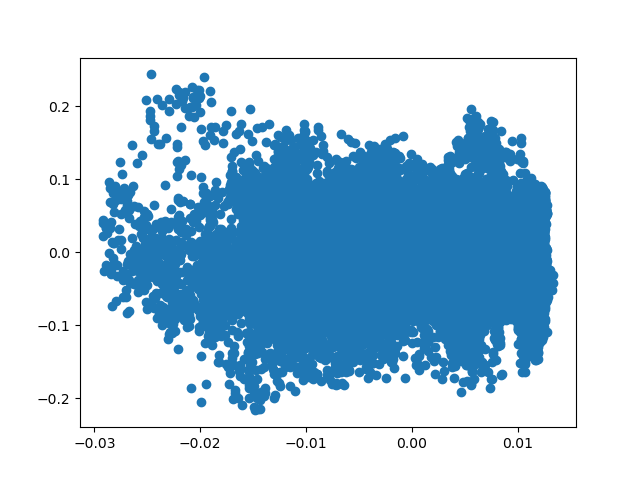

In [129]:
fig = plt.figure()
plt.scatter(DITD_ctd.abs_sal_anom,DITD_vel.v_along)

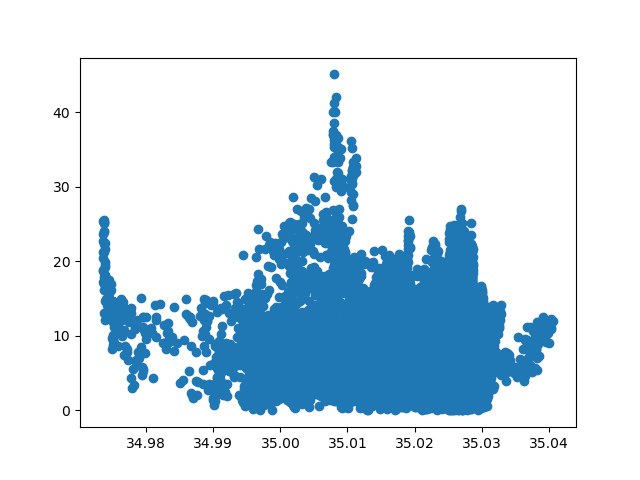

In [132]:
fig = plt.figure()
plt.scatter(TNBD_ctd.abs_sal,TNBD_vel.speed)


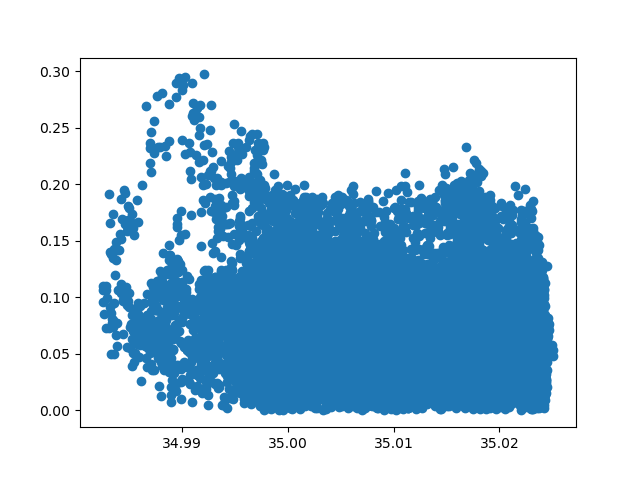

In [133]:
fig = plt.figure()
plt.scatter(DITD_ctd.abs_sal,DITD_vel.speed)

### Compute Transports 

In [72]:
def compute_transports(v_along, salinity, temperature,
                       A, rho=1027.0, cp=3985.0, T_ref=-1.9):
    """
    Compute volume, salt, and heat transport time series.
    
    Parameters
    ----------
    v_along     : along-trough velocity (m/s), already low-pass filtered
    salinity    : practical salinity (g/kg)
    temperature : in-situ or potential temperature (°C)
    A           : cross-sectional area (m²)
    rho         : reference density (kg/m³) — ideally compute from T/S
    cp          : specific heat capacity (J/kg/K)
    T_ref       : reference temperature (°C) for heat transport
                  Use surface freezing point (~-1.9°C) for shelf work
    
    Returns
    -------
    dict of transport arrays, all as time series
    """
    Q   = v_along * A                              # m³/s
    F_S = rho * v_along * salinity * A             # kg/s
    F_H = rho * cp * v_along * (temperature - T_ref) * A  # W
    
    return {
        'Q_m3s':         Q,
        'Q_Sv':          Q / 1e6,
        'salt_flux_kgs': F_S,
        'heat_flux_W':   F_H,
        'heat_flux_GW':  F_H / 1e9,
    }

In [84]:
W = 10000 # m, width of HSSW layer based on Rossby radius of deformation 
L = 500  #m, thickness of HSSW layer based on PIPERS CTD data 
A = L*W
Cp = 3980 # value used in budillon and spezie 2000 



In [85]:
# Along trough volume transport estimate 
Q_TNBD_along = A * TNBD_vel.u_prime
Q_DITD_along = A * DITD_vel.u_prime


In [86]:
# Across trough volume transport estimate 
Q_TNBD_across = A * TNBD_vel.v_prime
Q_DITD_across = A * DITD_vel.v_prime


Text(0.5, 0.98, 'TNBD 3-Day Rolling Average')

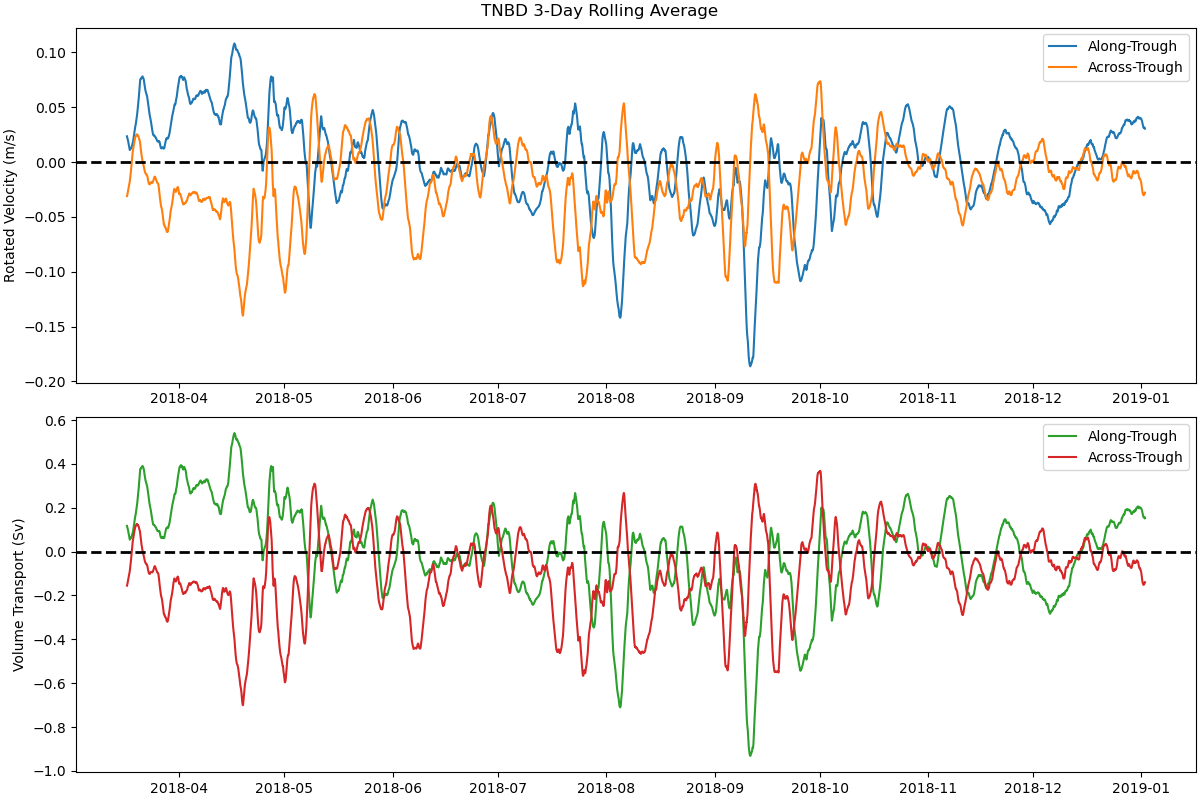

In [146]:
fig, ax = plt.subplots(nrows=2,ncols=1, figsize=(12,8), constrained_layout=True)

ax[0].plot(TNBD_vel.rolling(time=288).mean().time,TNBD_vel.rolling(time=288).mean().u_prime,label='Along-Trough')
ax[0].plot(TNBD_vel.rolling(time=288).mean().time,TNBD_vel.rolling(time=288).mean().v_prime, label='Across-Trough')
ax[0].set_ylabel('Rotated Velocity (m/s)')
ax[0].axhline(y=0, color="k", linestyle="--", linewidth=2)
ax[0].legend()


ax[1].plot(Q_TNBD_along.rolling(time=288).mean().time,Q_TNBD_along.rolling(time=288).mean()*1e-6,color='tab:green',label='Along-Trough')
ax[1].plot(Q_TNBD_across.rolling(time=288).mean().time,Q_TNBD_across.rolling(time=288).mean()*1e-6,color='tab:red', label='Across-Trough')
ax[1].set_ylabel('Volume Transport (Sv)')
ax[1].axhline(y=0, color="k", linestyle="--", linewidth=2)
ax[1].legend()

# ax[2].plot(Q_TNBD_across.rolling(time=288).mean().time,Q_TNBD_across.rolling(time=288).mean(),color='tab:red')
# ax[2].set_ylabel('Across-Trough Volume Transport')
# ax[2].axhline(y=0, color="k", linestyle="--", linewidth=2)


plt.suptitle('TNBD 3-Day Rolling Average')

Text(0.5, 0.98, 'DITD 3-Day Rolling Average')

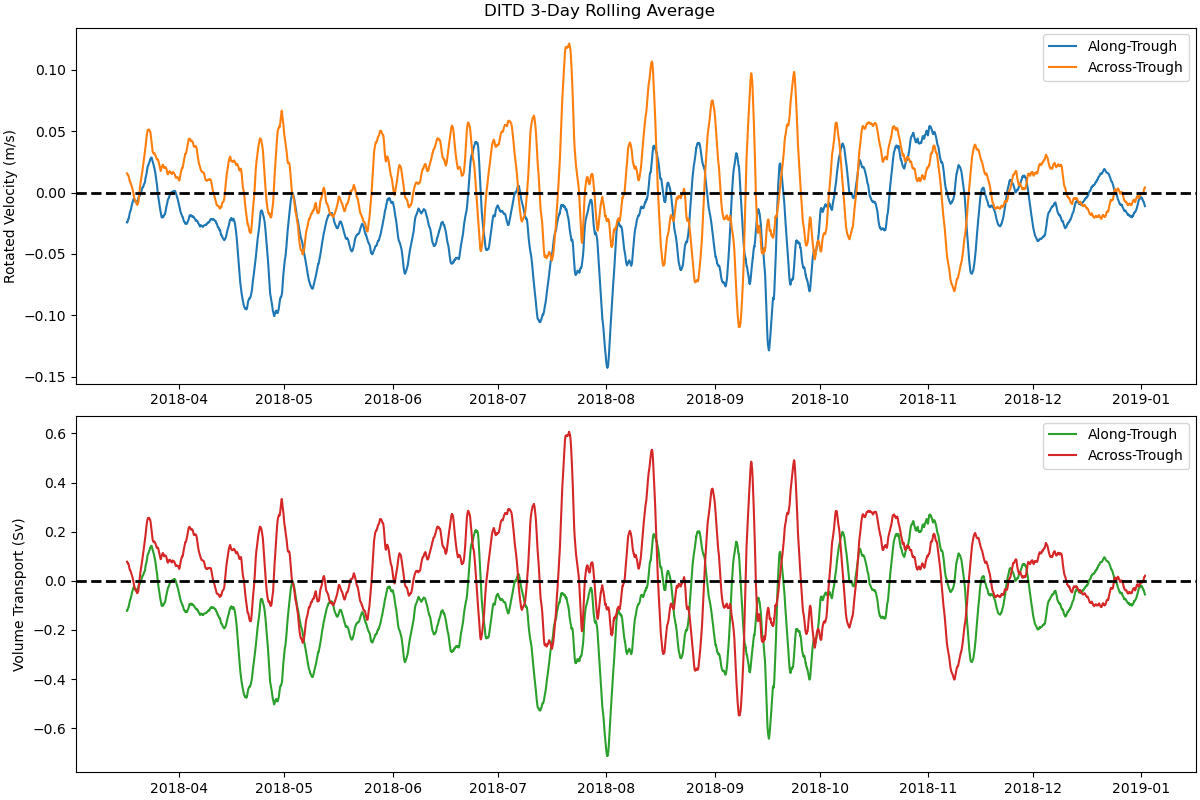

In [ ]:
fig, ax = plt.subplots(nrows=2,ncols=1, figsize=(12,8), constrained_layout=True)

ax[0].plot(DITD_vel.rolling(time=288).mean().time,DITD_vel.rolling(time=288).mean().u_prime,label='Along-Trough')
ax[0].plot(DITD_vel.rolling(time=288).mean().time,DITD_vel.rolling(time=288).mean().v_prime, label='Across-Trough')
ax[0].set_ylabel('Rotated Velocity (m/s)')
ax[0].axhline(y=0, color="k", linestyle="--", linewidth=2)
ax[0].legend()


ax[1].plot(Q_DITD_along.rolling(time=288).mean().time,Q_DITD_along.rolling(time=288).mean()*1e-6,color='tab:green',label='Along-Trough')
ax[1].plot(Q_DITD_across.rolling(time=288).mean().time,Q_DITD_across.rolling(time=288).mean()*1e-6,color='tab:red', label='Across-Trough')
ax[1].set_ylabel('Volume Transport (Sv)')
ax[1].axhline(y=0, color="k", linestyle="--", linewidth=2)
ax[1].legend()

plt.suptitle('DITD 3-Day Rolling Average')

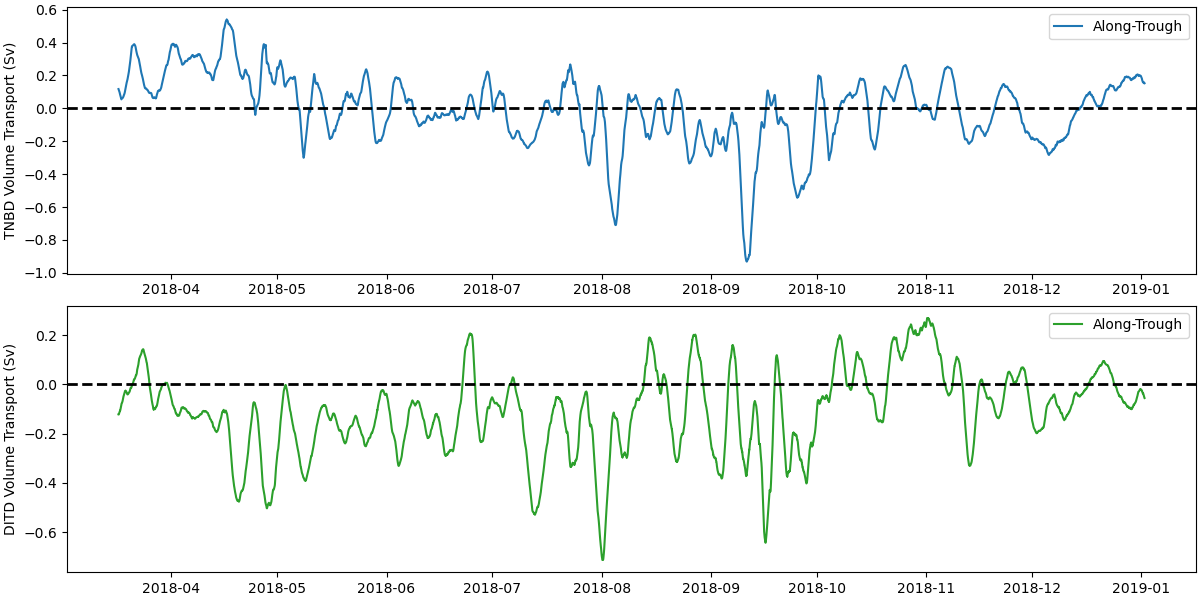

In [148]:
fig, ax = plt.subplots(nrows=2,ncols=1, figsize=(12,6), constrained_layout=True)

ax[0].plot(Q_TNBD_along.rolling(time=288).mean().time,Q_TNBD_along.rolling(time=288).mean()*1e-6,color='tab:blue',label='Along-Trough')
ax[0].set_ylabel('TNBD Volume Transport (Sv)')
ax[0].axhline(y=0, color="k", linestyle="--", linewidth=2)
ax[0].legend()


ax[1].plot(Q_DITD_along.rolling(time=288).mean().time,Q_DITD_along.rolling(time=288).mean()*1e-6,color='tab:green',label='Along-Trough')
# ax[1].plot(Q_DITD_across.rolling(time=288).mean().time,Q_DITD_across.rolling(time=288).mean()*1e-6,color='tab:red', label='Across-Trough')
ax[1].set_ylabel('DITD Volume Transport (Sv)')
ax[1].axhline(y=0, color="k", linestyle="--", linewidth=2)
ax[1].legend()

# plt.suptitle('DITD 3-Day Rolling Average')

In [151]:
Q_DITD_along.mean()*1e-6

<xarray.DataArray 'u_prime' ()> Size: 8B
array(-0.1120818)
Coordinates:
    z        int64 8B 1121
    lat      float64 8B -75.28
    lon      float64 8B 164.1

In [161]:
Q_DITD_along.sel(time=slice('2018-03','2018-05')).mean()*1e-6

<xarray.DataArray 'u_prime' ()> Size: 8B
array(-0.15864827)
Coordinates:
    z        int64 8B 1121
    lat      float64 8B -75.28
    lon      float64 8B 164.1

In [ ]:
Q_TNBD_alongQ_TNBD_along.mean()*1e-6

<xarray.DataArray 'u_prime' ()> Size: 8B
array(-0.00360417)
Coordinates:
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...

In [ ]:
# # Salt transport estimate (NEED TO FIGURE OUT REFERENCE VALUE TO USE)
# Fs_TNBD = (TNBD_ctd.sigma0+1000) * TNBD_ctd.abs_sal * Q_TNBD
# Fs_DITD = DITD_ctd.sigma0 * DITD_ctd.abs_sal * Q_DITD

In [ ]:
# # Heat transport estimate (NEED TO FIGURE OUT WHAT REFERENCE OT USE)
# Fh_TNBD = Q_TNBD * Cp * (TNBD_ctd.sigma0+1000) * (TNBD_ctd.theta + 273.15)
# Fh_DITD = Q_DITD * Cp * DITD_ctd.sigma0 * (DITD_ctd.theta +273.15)

In [87]:
# fig, ax = plt.subplots(nrows=3,ncols=1, figsize=(12,8), constrained_layout=True)

# ax[0].plot(TNBD_vel.rolling(time=288).mean().time,TNBD_vel.rolling(time=288).mean().u_prime)
# ax[0].set_ylabel('Along-trough Velocity (m/s)')
# ax[0].axhline(y=0, color="k", linestyle="--", linewidth=2)

# ax[1].plot(Fs_TNBD.rolling(time=288).mean().time,Fs_TNBD.rolling(time=288).mean(),color='tab:green')
# ax[1].set_ylabel('Salt Transport (g/sec)')
# ax[1].axhline(y=0, color="k", linestyle="--", linewidth=2)

# ax[2].plot(Fh_TNBD.rolling(time=288).mean().time,Fh_TNBD.rolling(time=288).mean(),color='tab:red')
# ax[2].set_ylabel('Heat Transport (J/sec)')
# ax[2].axhline(y=0, color="k", linestyle="--", linewidth=2)


# plt.suptitle('TNBD 3-Day Rolling Average')

In [88]:
# fig, ax = plt.subplots(nrows=3,ncols=1, figsize=(12,8), constrained_layout=True)

# ax[0].plot(DITD_vel.rolling(time=288).mean().time,DITD_vel.rolling(time=288).mean().u_prime)
# ax[0].set_ylabel('Along-trough Velocity (m/s)')
# ax[0].axhline(y=0, color="k", linestyle="--", linewidth=2)

# ax[1].plot(Fs_DITD.rolling(time=288).mean().time,Fs_DITD.rolling(time=288).mean(),color='tab:green')
# ax[1].set_ylabel('Salt Transport (g/sec)')
# ax[1].axhline(y=0, color="k", linestyle="--", linewidth=2)

# ax[2].plot(Fh_DITD.rolling(time=288).mean().time,Fh_DITD.rolling(time=288).mean(),color='tab:red')
# ax[2].set_ylabel('Heat Transport (J/sec)')
# ax[2].axhline(y=0, color="k", linestyle="--", linewidth=2)


# plt.suptitle('DITD 3-Day Rolling Average')

### Load in wind speed data 

In [44]:
wspd = xr.open_dataset("C:/Users/mblan/Documents/TNB_Research/data/AWS_Manuela/AWS_Manuela_2001_2025.nc")

In [45]:
TNBD_vel.time.values

array(['2018-03-14T00:00:00.000000000', '2018-03-14T00:15:00.000000000',
       '2018-03-14T00:30:00.000000000', ...,
       '2019-01-01T23:15:00.000000000', '2019-01-01T23:30:00.000000000',
       '2019-01-01T23:45:00.000000000'],
      shape=(28224,), dtype='datetime64[ns]')

In [46]:
# crop to 2018 
wspd = wspd.sel(time=slice('2018-03-14','2019-01-01'))

In [47]:
wspd_15 = wspd.resample(time='15min').mean()

In [48]:
wspd_15

<xarray.Dataset> Size: 2MB
Dimensions:            (time: 28224)
Coordinates:
  * time               (time) datetime64[ns] 226kB 2018-03-14 ... 2019-01-01T...
Data variables:
    temp               (time) float64 226kB -14.65 -14.6 -14.55 ... -2.95 -2.9
    pressure           (time) float64 226kB 981.8 981.8 981.5 ... 974.6 974.5
    wind_speed         (time) float64 226kB 17.0 18.4 17.7 ... 17.1 16.15 16.6
    wind_dir           (time) float64 226kB 271.5 271.0 271.5 ... 262.5 261.0
    relative_humidity  (time) float64 226kB 73.0 69.0 72.33 ... 60.6 59.5 58.9
    delta-temp         (time) float64 226kB nan nan nan nan ... nan nan nan nan

Text(0.5, 0.98, 'TNBD')

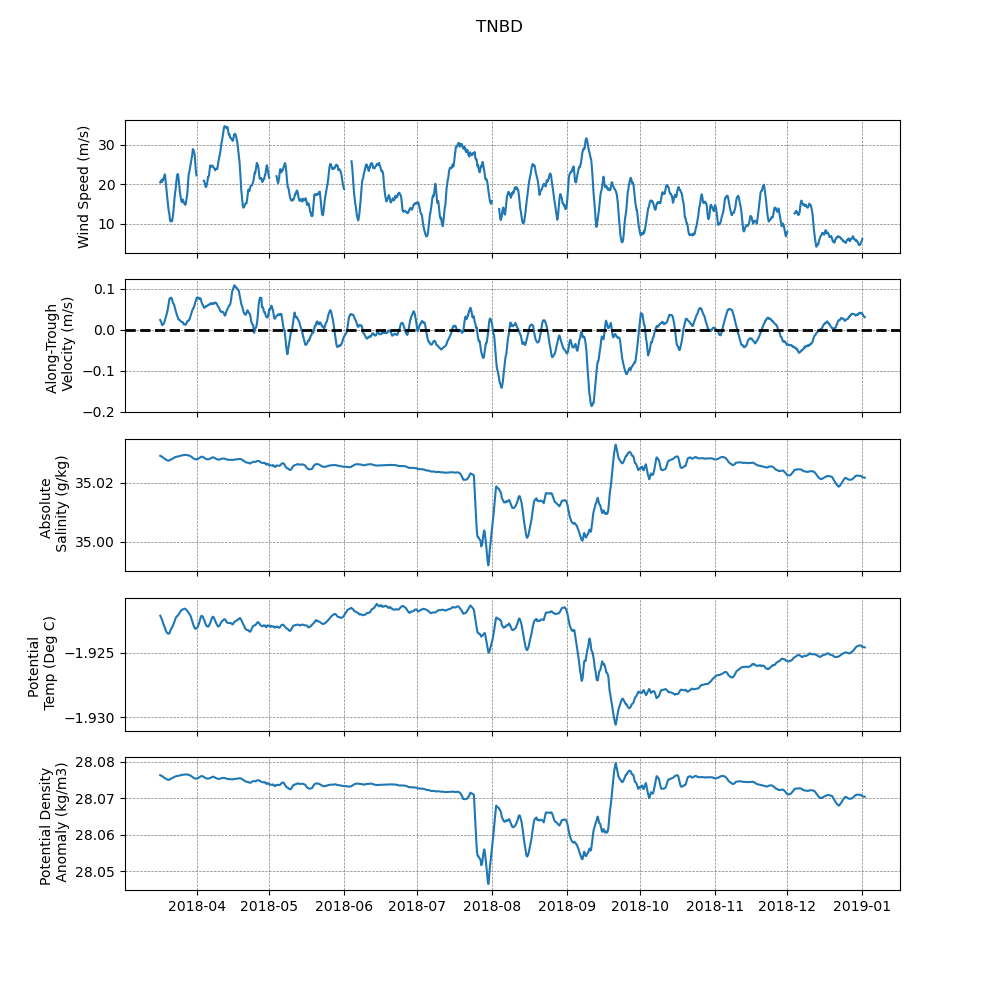

In [49]:
# define rolling average 
rolling = 288
# plot timeseries of along trough velocity, wind speed, salinity, temperature, density, SIC 
fig, ax = plt.subplots(nrows=5,ncols=1,figsize=(10,10),sharex=True)

# WIND SPEED 
ax[0].plot(wspd_15.rolling(time=rolling).mean().time,wspd_15.rolling(time=rolling).mean().wind_speed)
ax[0].set_ylabel('Wind Speed (m/s)')
ax[0].tick_params(labelbottom=False)

# Along Trough Velocity 
ax[1].plot(TNBD_vel.rolling(time=rolling).mean().time,TNBD_vel.rolling(time=rolling).mean().u_prime)
ax[1].axhline(y=0, color="k", linestyle="--", linewidth=2)
ax[1].set_ylabel('Along-Trough \n Velocity (m/s)')
ax[1].tick_params(labelbottom=False)

# Absolute Salinity 
ax[2].plot(TNBD_ctd.rolling(time=rolling).mean().time,TNBD_ctd.rolling(time=rolling).mean().abs_sal)
ax[2].set_ylabel('Absolute \n Salinity (g/kg)')
ax[2].tick_params(labelbottom=False)

# Potential Temp 
ax[3].plot(TNBD_ctd.rolling(time=rolling).mean().time,TNBD_ctd.rolling(time=rolling).mean().theta)
ax[3].set_ylabel('Potential \n Temp (Deg C)')
ax[3].tick_params(labelbottom=False)

# potential density anomaly 
ax[4].plot(TNBD_ctd.rolling(time=rolling).mean().time,TNBD_ctd.rolling(time=rolling).mean().sigma0)
ax[4].set_ylabel('Potential Density \n Anomaly (kg/m3)')

# Loop through each axes object to enable vertical grids
for axs in ax:
    # axs.plot([1, 2, 3], [4, 5, 6])
    axs.grid(True, axis='both', color='gray', linestyle='--', linewidth=0.5)

plt.suptitle('TNBD')

Text(0.5, 0.98, 'DITD')

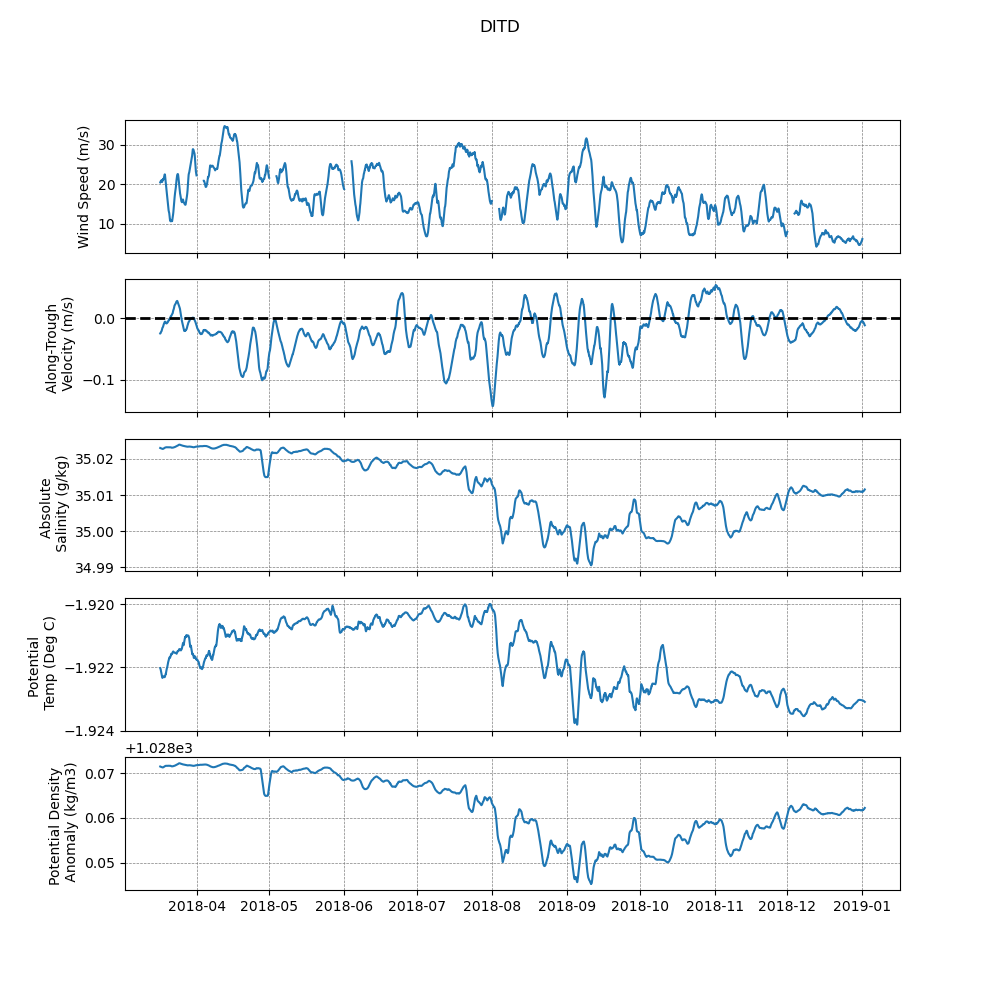

In [50]:
# define rolling average 
rolling = 288
# plot timeseries of along trough velocity, wind speed, salinity, temperature, density, SIC 
fig, ax = plt.subplots(nrows=5,ncols=1,figsize=(10,10),sharex=True)

# WIND SPEED 
ax[0].plot(wspd_15.rolling(time=rolling).mean().time,wspd_15.rolling(time=rolling).mean().wind_speed)
ax[0].set_ylabel('Wind Speed (m/s)')
ax[0].tick_params(labelbottom=False)

# Along Trough Velocity 
ax[1].plot(DITD_vel.rolling(time=rolling).mean().time,DITD_vel.rolling(time=rolling).mean().u_prime)
ax[1].axhline(y=0, color="k", linestyle="--", linewidth=2)
ax[1].set_ylabel('Along-Trough \n Velocity (m/s)')
ax[1].tick_params(labelbottom=False)

# Absolute Salinity 
ax[2].plot(DITD_ctd.rolling(time=rolling).mean().time,DITD_ctd.rolling(time=rolling).mean().abs_sal)
ax[2].set_ylabel('Absolute \n Salinity (g/kg)')
ax[2].tick_params(labelbottom=False)

# Potential Temp 
ax[3].plot(DITD_ctd.rolling(time=rolling).mean().time,DITD_ctd.rolling(time=rolling).mean().theta)
ax[3].set_ylabel('Potential \n Temp (Deg C)')
ax[3].tick_params(labelbottom=False)

# potential density anomaly 
ax[4].plot(DITD_ctd.rolling(time=rolling).mean().time,DITD_ctd.rolling(time=rolling).mean().sigma0)
ax[4].set_ylabel('Potential Density \n Anomaly (kg/m3)')

# Loop through each axes object to enable vertical grids
for axs in ax:
    # axs.plot([1, 2, 3], [4, 5, 6])
    axs.grid(True, axis='both', color='gray', linestyle='--', linewidth=0.5)

plt.suptitle('DITD')

### Load in SIC data 

In [112]:
import glob

In [113]:
files = glob.glob(
    r"C:\Users\mblan\Documents\TNB_Research\data\SIC_Ross\**\*.nc",
    recursive=True
)

In [114]:
files

['C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\SIC_Ross_2016_2019.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\SIC_TNB_2016_2019.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2016\\asi-AMSR2-s3125-20160101-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2016\\asi-AMSR2-s3125-20160102-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2016\\asi-AMSR2-s3125-20160103-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2016\\asi-AMSR2-s3125-20160104-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2016\\asi-AMSR2-s3125-20160105-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2016\\asi-AMSR2-s3125-20160106-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2016\\asi-AMSR2-s3125-20160107-v5.4.nc',
 'C:\\Users\\mblan\\Documents\\TNB_Research\\data\\SIC_Ross\\2016\\asi-AMSR2-s3125-20160108-v5.4.nc',
 'C:\\Users\\mb

In [115]:
import glob
import xarray as xr

files = glob.glob(
    r"C:\Users\mblan\Documents\TNB_Research\data\SIC_Ross\**\*.nc",
    recursive=True
)

sic = xr.open_mfdataset(
    files,
    combine="by_coords"
)

print(sic)

C:\Users\mblan\AppData\Local\Temp\ipykernel_12620\2473576933.py:9: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'x' ('x',) The recommendation is to set join explicitly for this case.
  sic = xr.open_mfdataset(

KeyboardInterrupt



In [116]:
one = xr.open_dataset(files[1])


In [117]:
print(one)

<xarray.Dataset> Size: 218MB
Dimensions:              (time: 1461, x: 102, y: 122)
Coordinates:
  * time                 (time) datetime64[ns] 12kB 2016-01-01 ... 2019-12-31
  * x                    (x) float64 816B 3.172e+05 3.203e+05 ... 6.328e+05
    lon                  (y, x) float64 100kB ...
    lat                  (y, x) float64 100kB ...
  * y                    (y) float64 976B -1.811e+06 -1.808e+06 ... -1.433e+06
Data variables:
    polar_stereographic  (time, x, y) |S8 145MB ...
    sic                  (time, y, x) float32 73MB ...
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:39 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27


In [118]:
import xarray as xr
import pandas as pd
import glob
import re
import numpy as np

In [119]:
def get_time_from_filename(fname):
    match = re.search(r'(\d{8})', fname)
    if match is None:
        raise ValueError(f"No date found in filename: {fname}")
    return pd.to_datetime(match.group(1), format='%Y%m%d')

In [120]:
files = glob.glob(
    r"C:\Users\mblan\Documents\TNB_Research\data\SIC_Ross\**\*.nc",
    recursive=True
)

datasets = []

for f in files:
    ds = xr.open_dataset(f)

    # rename variable if needed
    ds = ds.rename({"z": "sic"})  # sea ice concentration

    # add time dimension
    time = get_time_from_filename(f)
    ds = ds.expand_dims({"time": [time]})

    datasets.append(ds)

ValueError: cannot rename 'z' because it is not a variable or dimension in this dataset

In [115]:
len(datasets)

1461

In [116]:
datasets[9]

<xarray.Dataset> Size: 27MB
Dimensions:              (time: 1, y: 2656, x: 2528)
Coordinates:
  * time                 (time) datetime64[ns] 8B 2016-01-10
  * y                    (y) float64 21kB -3.948e+06 -3.945e+06 ... 4.348e+06
  * x                    (x) float64 20kB -3.948e+06 -3.945e+06 ... 3.948e+06
Data variables:
    polar_stereographic  (time) |S1 1B b''
    sic                  (time, y, x) float32 27MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:58 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27

In [117]:
ds_all = xr.concat(datasets, dim="time")

In [118]:
ds_all

<xarray.Dataset> Size: 39GB
Dimensions:              (time: 1461, y: 2656, x: 2528)
Coordinates:
  * time                 (time) datetime64[ns] 12kB 2016-01-01 ... 2019-12-31
  * y                    (y) float64 21kB -3.948e+06 -3.945e+06 ... 4.348e+06
  * x                    (x) float64 20kB -3.948e+06 -3.945e+06 ... 3.948e+06
Data variables:
    polar_stereographic  (time) |S1 1kB b'' b'' b'' b'' b'' ... b'' b'' b'' b''
    sic                  (time, y, x) float32 39GB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:39 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27

In [119]:
# rough Ross Sea bounds (you may tweak)
x_min, x_max = -2.2e6, 1.5e6
y_min, y_max = -2.2e6, -0.2e6

In [120]:
ds_ross = ds_all.where(
    (ds_all.x >= x_min) &
    (ds_all.x <= x_max) &
    (ds_all.y >= y_min) &
    (ds_all.y <= y_max),
    drop=True
)

In [121]:
ds_ross

<xarray.Dataset> Size: 13GB
Dimensions:              (time: 1461, x: 1184, y: 640)
Coordinates:
  * time                 (time) datetime64[ns] 12kB 2016-01-01 ... 2019-12-31
  * x                    (x) float64 9kB -2.198e+06 -2.195e+06 ... 1.498e+06
  * y                    (y) float64 5kB -2.198e+06 -2.195e+06 ... -2.016e+05
Data variables:
    polar_stereographic  (time, x, y) object 9GB b'' b'' b'' b'' ... b'' b'' b''
    sic                  (time, y, x) float32 4GB 0.0 0.0 0.0 ... nan nan nan
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:39 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27

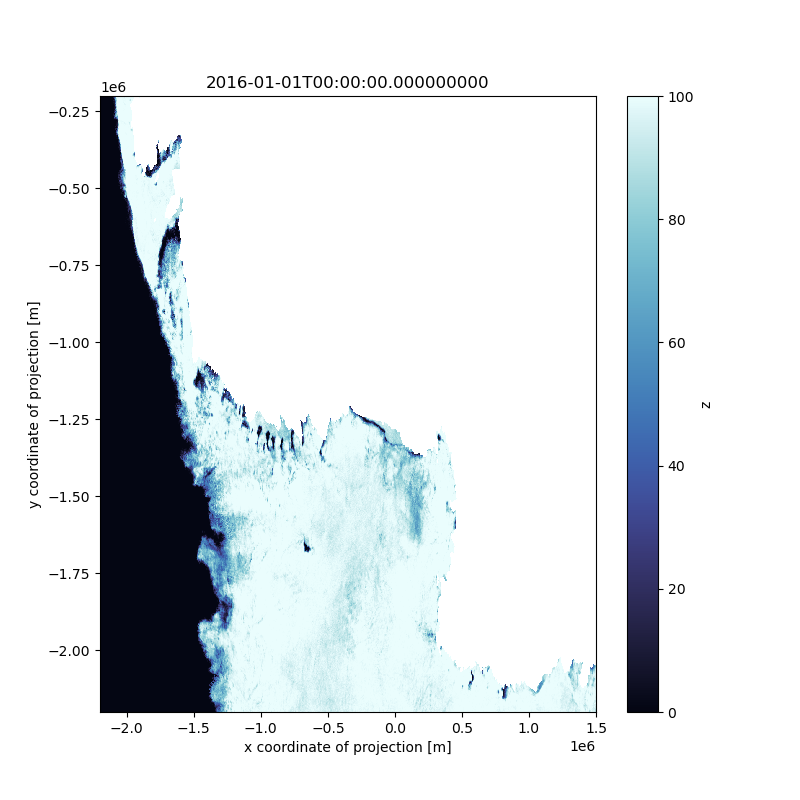

In [123]:
ds_ross.sic.isel(time=500).plot(
    cmap=cmocean.cm.ice,
    vmin=0,
    vmax=100,
    figsize=(8,8)
)

plt.title(str(ds_ross.time.isel(time=0).values))
plt.show()

In [124]:
x_min = 0.2e6
x_max = 0.9e6

y_min = -2.5e6
y_max = -1.6e6

In [125]:
ds_tnb = ds_ross.where(
    (ds_ross.x >= x_min) &
    (ds_ross.x <= x_max) &
    (ds_ross.y >= y_min) &
    (ds_ross.y <= y_max),
    drop=True
)

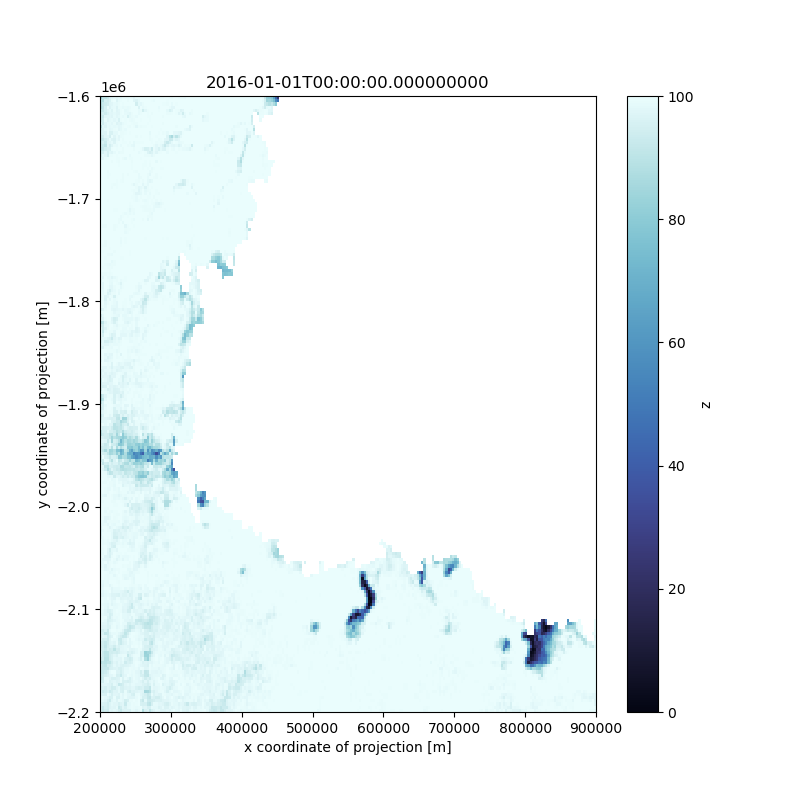

In [126]:
ds_tnb.sic.isel(time=500).plot(
    cmap=cmocean.cm.ice,
    vmin=0,
    vmax=100,
    figsize=(8,8)
)

plt.title(str(ds_tnb.time.isel(time=0).values))
plt.show()

In [ ]:
ds_ross.to_netcdf('/Users/mblan/Documents/TNB_Research/data/SIC_Ross/SIC_Ross_2016_2019.nc')

In [121]:
ds_ross = xr.open_dataset('/Users/mblan/Documents/TNB_Research/data/SIC_Ross/SIC_Ross_2016_2019.nc')

In [122]:
ds_ross.polar_stereographic

<xarray.DataArray 'polar_stereographic' (time: 1461, x: 1184, y: 640)> Size: 9GB
[1107087360 values with dtype=|S8]
Coordinates:
  * time     (time) datetime64[ns] 12kB 2016-01-01 2016-01-02 ... 2019-12-31
  * x        (x) float64 9kB -2.198e+06 -2.195e+06 ... 1.495e+06 1.498e+06
  * y        (y) float64 5kB -2.198e+06 -2.195e+06 ... -2.047e+05 -2.016e+05
Attributes: (12/13)
    grid_mapping_name:                      polar_stereographic
    latitude_of_projection_origin:          -90.0
    standard_parallel:                      -70.0
    straight_vertical_longitude_from_pole:  0.0
    false_easting:                          0.0
    false_northing:                         0.0
    ...                                     ...
    longitude_of_prime_meridian:            0.0
    semi_major_axis:                        6378137.0
    inverse_flattening:                     298.257223563
    spatial_ref:                            PROJCS["WGS 84 / NSIDC Sea Ice Po...
    crs_wkt:                                PROJCS["WGS 84 / NSIDC Sea Ice Po...
    GeoTransform:                           -3950000 3125 0 4350000 0 -3125

In [125]:
import pyproj

crs_ps = pyproj.CRS.from_cf(
    ds_ross.polar_stereographic.attrs
)

crs_ps

<Projected CRS: EPSG:3976>
Name: WGS 84 / NSIDC Sea Ice Polar Stereographic South
Axis Info [cartesian]:
- [north]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Polar Stereographic (variant B)
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [126]:
from pyproj import Transformer

transformer = Transformer.from_crs(
    crs_ps,
    "EPSG:4326",
    always_xy=True
)

In [127]:
import numpy as np

X, Y = np.meshgrid(
    ds_ross.x.values,
    ds_ross.y.values
)

lon, lat = transformer.transform(X, Y)

In [128]:
ds_ross = ds_ross.assign_coords(
    lon=(("y","x"), lon),
    lat=(("y","x"), lat)
)

In [129]:
ds_ross

<xarray.Dataset> Size: 13GB
Dimensions:              (time: 1461, x: 1184, y: 640)
Coordinates:
  * time                 (time) datetime64[ns] 12kB 2016-01-01 ... 2019-12-31
  * x                    (x) float64 9kB -2.198e+06 -2.195e+06 ... 1.498e+06
    lon                  (y, x) float64 6MB -135.0 -135.0 -135.1 ... 97.68 97.66
    lat                  (y, x) float64 6MB -61.86 -61.88 ... -76.14 -76.11
  * y                    (y) float64 5kB -2.198e+06 -2.195e+06 ... -2.016e+05
Data variables:
    polar_stereographic  (time, x, y) |S8 9GB ...
    sic                  (time, y, x) float32 4GB ...
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:39 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27

In [130]:
tnb = ds_ross.where(
    (ds_ross.lon >= 160) &
    (ds_ross.lon <= 168) &
    (ds_ross.lat >= -76) &
    (ds_ross.lat <= -73),
    drop=True
)

In [131]:
tnb

<xarray.Dataset> Size: 218MB
Dimensions:              (time: 1461, x: 102, y: 122)
Coordinates:
  * time                 (time) datetime64[ns] 12kB 2016-01-01 ... 2019-12-31
  * x                    (x) float64 816B 3.172e+05 3.203e+05 ... 6.328e+05
    lon                  (y, x) float64 100kB 170.1 170.0 169.9 ... 156.3 156.2
    lat                  (y, x) float64 100kB -73.15 -73.14 ... -75.63 -75.61
  * y                    (y) float64 976B -1.811e+06 -1.808e+06 ... -1.433e+06
Data variables:
    polar_stereographic  (time, x, y) object 145MB nan nan nan ... nan nan nan
    sic                  (time, y, x) float32 73MB nan nan nan ... nan nan nan
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:39 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27

c:\Users\mblan\miniforge3\envs\TNB\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


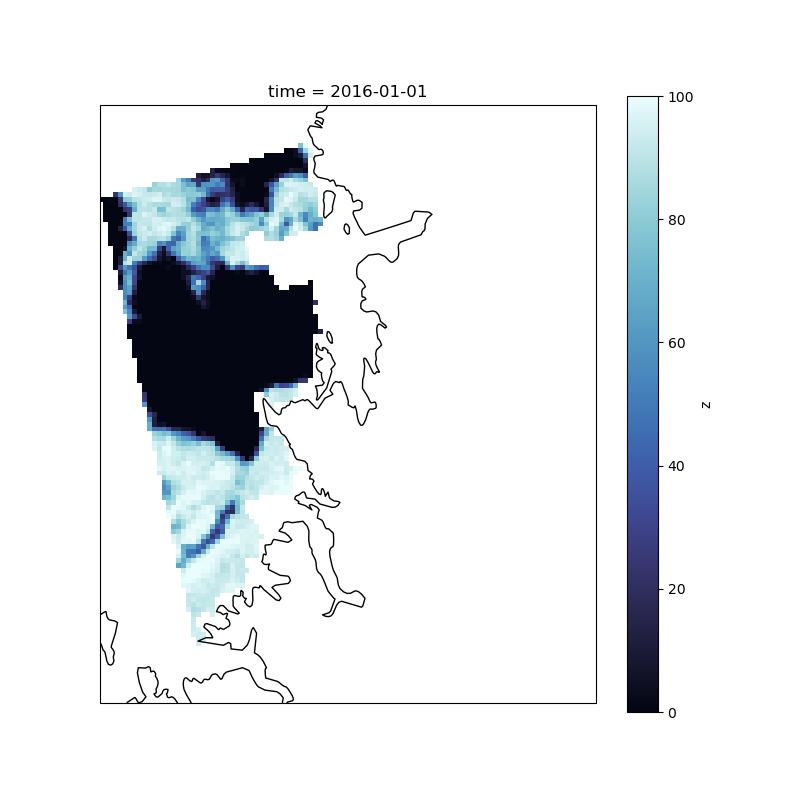

In [137]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cmocean

fig = plt.figure(figsize=(8,8))

ax = plt.axes(
    projection=ccrs.SouthPolarStereo()
)

ax.coastlines()

tnb.sic.isel(time=0).plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.ice,
    vmin=0,
    vmax=100
)

ax.set_extent(
    [160,168,-76,-73],
    crs=ccrs.PlateCarree()
)

plt.show()

In [138]:
tnb.to_netcdf('/Users/mblan/Documents/TNB_Research/data/SIC_Ross/SIC_TNB_2016_2019.nc')

In [51]:
# open TNB dataset 
tnb = xr.open_dataset('/Users/mblan/Documents/TNB_Research/data/SIC_Ross/SIC_TNB_2016_2019.nc')

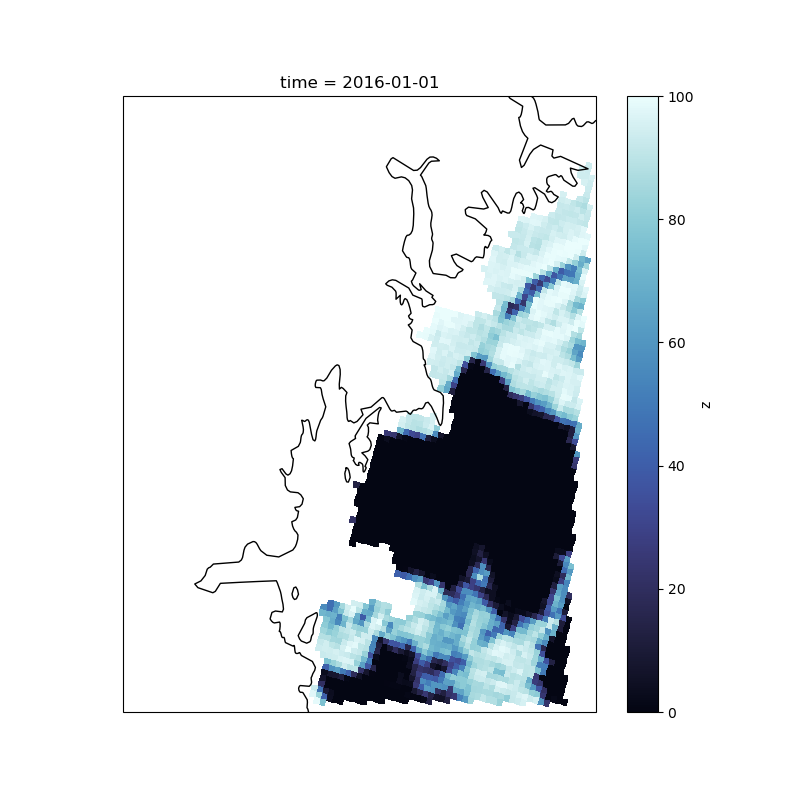

In [52]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cmocean

fig = plt.figure(figsize=(8,8))

ax = plt.axes(
    projection=ccrs.SouthPolarStereo(
        central_longitude=165
    )
)

ax.coastlines()

tnb.sic.isel(time=0).plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.ice,
    vmin=0,
    vmax=100
)

ax.set_extent(
    [160,168,-76,-73],
    crs=ccrs.PlateCarree()
)

plt.show()

In [53]:
tnb

<xarray.Dataset> Size: 218MB
Dimensions:              (time: 1461, x: 102, y: 122)
Coordinates:
  * time                 (time) datetime64[ns] 12kB 2016-01-01 ... 2019-12-31
  * x                    (x) float64 816B 3.172e+05 3.203e+05 ... 6.328e+05
    lon                  (y, x) float64 100kB ...
    lat                  (y, x) float64 100kB ...
  * y                    (y) float64 976B -1.811e+06 -1.808e+06 ... -1.433e+06
Data variables:
    polar_stereographic  (time, x, y) |S8 145MB ...
    sic                  (time, y, x) float32 73MB ...
Attributes:
    author:       University of Bremen, Gunnar Spreen [gunnar.spreen@uni-brem...
    Conventions:  CF-1.5
    GMT_version:  6.3.0 [64-bit]
    history:      Wed May 29 16:59:39 2024: GDAL CreateCopy( /mnt/web//data/a...
    info:         AMSR2 sea ice concentration based on the ASI algorithm (Spr...
    title:        Produced by grdmath
    GDAL:         GDAL 3.4.1, released 2021/12/27

In [12]:
tnb_anim = tnb.sel(time=slice('2018-07-01','2018-08-01'))

In [13]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cmocean
import matplotlib.animation as animation


# Create figure
fig = plt.figure(figsize=(8,8))

ax = plt.axes(
    projection=ccrs.SouthPolarStereo(
        central_longitude=165
    )
)

ax.coastlines()

ax.set_extent(
    [160,168,-76,-73],
    crs=ccrs.PlateCarree()
)


# initial frame
sic_plot = tnb_anim.sic.isel(time=0).plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.ice,
    vmin=0,
    vmax=100,
    add_colorbar=True
)

# title
title = ax.set_title(
    str(tnb_anim.time.isel(time=0).values)[:10]
)


# animation function
def update(frame):

    # get new SIC
    sic = tnb_anim.sic.isel(time=frame)

    # update color values
    sic_plot.set_array(
        sic.values.ravel()
    )

    # update title
    title.set_text(
        tnb_anim.time.isel(time=frame).dt.strftime("%Y-%m-%d").item()
    )

    return [sic_plot, title]


# create animation
ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(tnb_anim.time),
    interval=200,   # milliseconds between frames
    blit=False
)


# save mp4
ani.save(
    "TNB_SIC_animation_July.mp4",
    writer="ffmpeg",
    fps=5,
    dpi=200
)


plt.close()

In [166]:
!conda install -c conda-forge ffmpeg

^C


In [54]:
tnb_zoomed = tnb.where(
    (tnb.lon >= 163) &
    (tnb.lon <= 166) &
    (tnb.lat >= -75.5) &
    (tnb.lat <= -74.7),
    drop=True
)

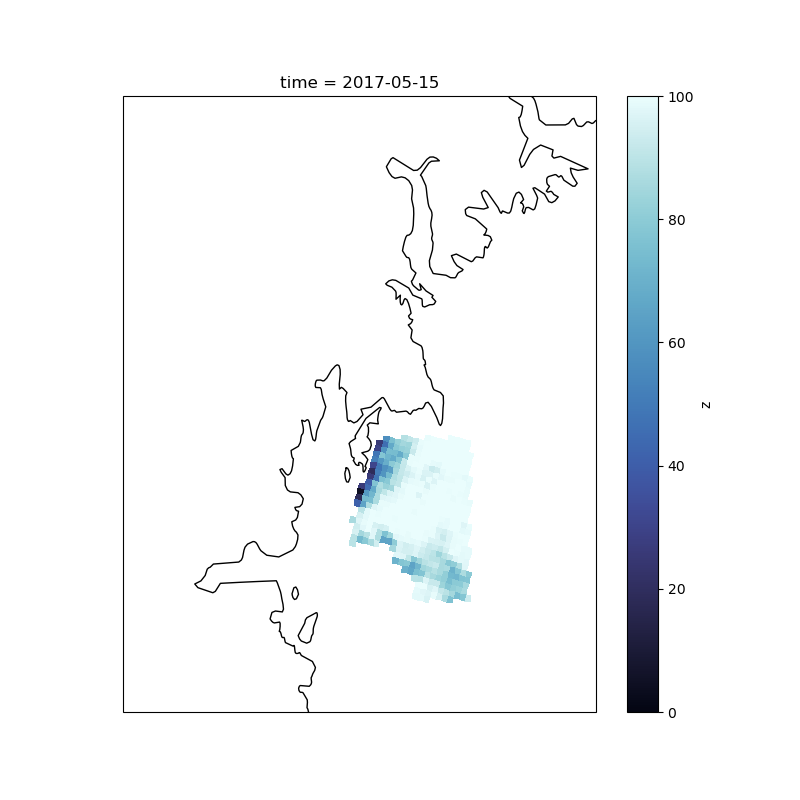

In [55]:
fig = plt.figure(figsize=(8,8))

ax = plt.axes(
    projection=ccrs.SouthPolarStereo(
        central_longitude=165
    )
)

ax.coastlines()

tnb_zoomed.sic.isel(time=500).plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.ice,
    vmin=0,
    vmax=100
)

ax.set_extent(
    [160,168,-76,-73],
    crs=ccrs.PlateCarree()
)

plt.show()

In [56]:
# average TNB zoomed SIC to make timeseries 
tnb_SIC_ts = tnb_zoomed.sic.mean('x').mean('y')

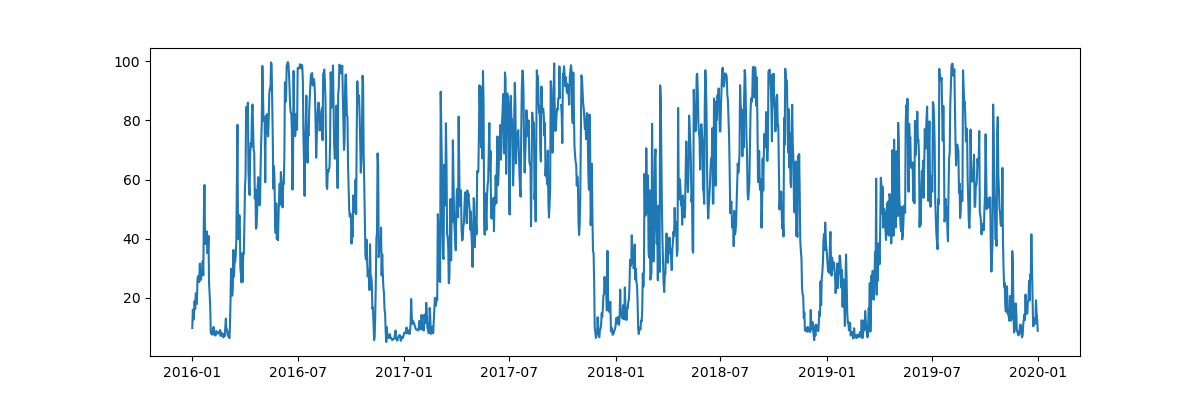

In [57]:
fig = plt.figure(figsize=(12,4))
plt.plot(tnb_SIC_ts.time,tnb_SIC_ts)

In [58]:
# crop to same time as rest of data 
tnb_sic_2018 = tnb_SIC_ts.sel(time=slice('2018-03-14','2019-01-01'))

In [59]:
tnb_sic_2018

<xarray.DataArray 'sic' (time: 294)> Size: 1kB
array([41.575397 , 25.970514 , 51.177036 , 36.57773  , 28.770227 ,
       91.76952  , 87.546074 , 69.64419  , 50.917515 , 39.06072  ,
       32.40408  , 24.93862  , 22.003614 , 27.627728 , 27.993519 ,
       36.859577 , 41.78334  , 38.500603 , 31.900694 , 39.48372  ,
       34.925682 , 40.40575  , 36.68937  , 36.37508  , 33.05788  ,
       29.402117 , 36.63937  , 38.693386 , 42.38453  , 40.87475  ,
       50.414013 , 44.67138  , 45.687267 , 41.470985 , 34.20173  ,
       35.97842  , 84.15688  , 57.382988 , 53.303925 , 60.07824  ,
       57.18806  , 51.284977 , 53.80071  , 44.76113  , 54.590523 ,
       51.95533  , 48.53544  , 47.15059  , 49.95015  , 62.60637  ,
       72.821045 , 63.02363  , 59.737137 , 55.760715 , 62.628292 ,
       81.56655  , 77.28877  , 72.75729  , 66.46863  , 52.491173 ,
       54.7412   , 35.985764 , 35.30544  , 90.30951  , 83.00887  ,
       80.60381  , 76.28734  , 79.49434  , 95.16136  , 95.72699  ,
       89.235886 , 79.24975  , 75.89908  , 73.73562  , 63.363827 ,
       71.92792  , 78.69555  , 75.96877  , 73.23028  , 56.528385 ,
       56.194996 , 51.77599  , 84.54323  , 96.906364 , 92.2751   ,
       83.24937  , 63.477787 , 51.49837  , 46.83455  , 51.093998 ,
       54.406002 , 58.55965  , 64.11413  , 67.178825 , 63.59136  ,
       77.338684 , 51.823734 , 51.906643 , 87.35769  , 69.0716   ,
...
       94.03987  , 91.32183  , 85.185875 , 72.937584 , 95.48577  ,
       92.98327  , 95.717354 , 85.72721  , 83.376884 , 76.27784  ,
       83.805145 , 87.87025  , 88.61273  , 77.9862   , 78.21058  ,
       63.32002  , 49.874634 , 53.543045 , 50.198696 , 55.955116 ,
       48.19902  , 43.42363  , 46.12007  , 40.76059  , 80.75752  ,
       71.646736 , 97.40407  , 94.288025 , 93.65281  , 93.09467  ,
       77.56381  , 69.12177  , 83.72757  , 64.01088  , 75.63694  ,
       59.279793 , 57.456257 , 78.50908  , 85.26145  , 72.2352   ,
       67.33911  , 53.352413 , 48.912067 , 59.09136  , 66.071465 ,
       41.010452 , 43.855522 , 40.58312  , 67.99956  , 56.56855  ,
       68.630615 , 55.4641   , 39.031464 , 35.812298 , 33.381985 ,
       23.411818 , 21.15144  , 20.664448 , 13.223246 , 15.099719 ,
        9.184386 ,  8.868482 ,  9.785188 ,  9.5994835,  8.615406 ,
       10.223398 ,  9.190341 ,  9.279395 ,  8.612343 ,  8.451007 ,
       15.944286 ,  9.576643 ,  9.302409 , 11.893381 ,  9.099279 ,
        7.6566434,  5.7519383, 10.452027 ,  7.207501 , 11.042637 ,
       10.778839 ,  9.275488 ,  9.922225 ,  8.760168 , 11.54637  ,
       15.466887 , 13.976702 , 25.608204 , 17.603426 , 26.518753 ,
       28.457735 , 31.78535  , 39.48771  , 41.600792 , 36.14322  ,
       45.44831  , 39.474594 , 36.853195 , 34.899654 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2018-03-14 2018-03-15 ... 2019-01-01
Attributes:
    long_name:     z
    actual_range:  [  0 100]
    grid_mapping:  polar_stereographic

NameError: name 'Q_TNBD_along' is not defined

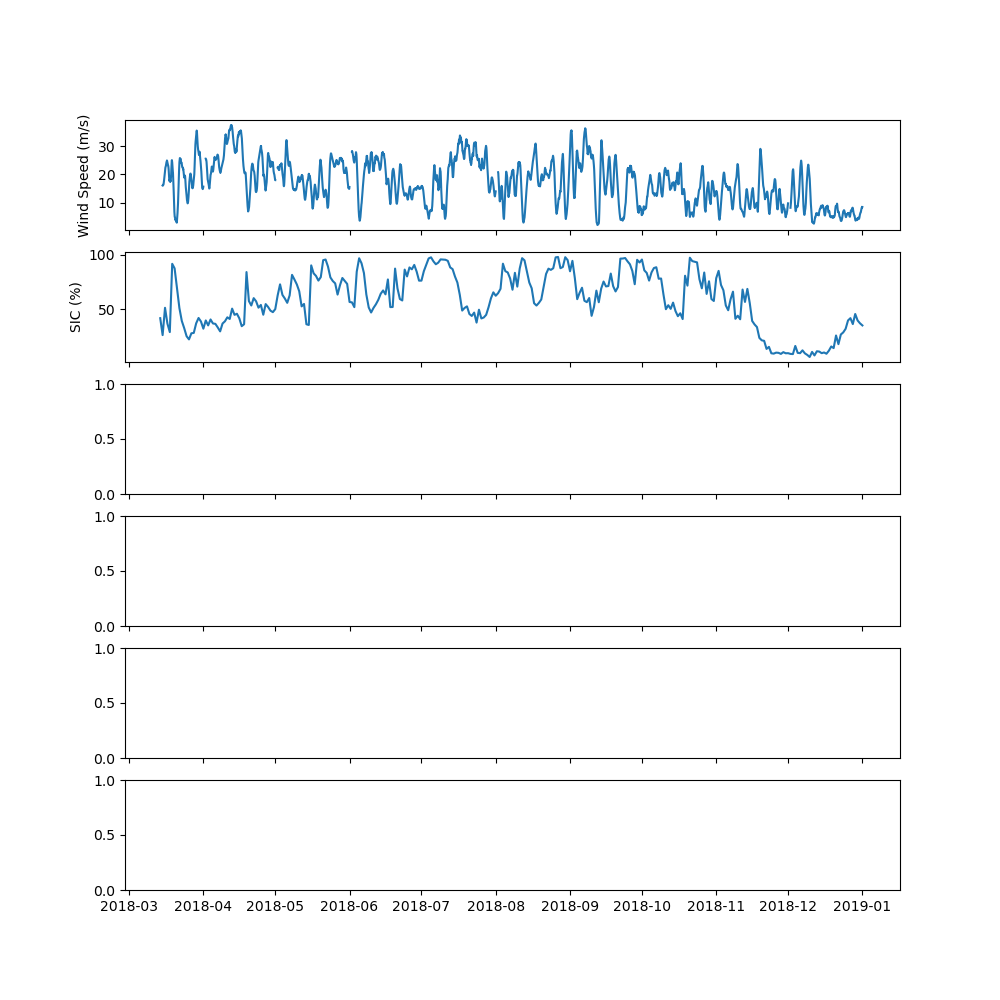

In [60]:
# define rolling average 
rolling = 96 # daily 
# plot timeseries of along trough velocity, wind speed, salinity, temperature, density, SIC 
fig, ax = plt.subplots(nrows=6,ncols=1,figsize=(10,10),sharex=True)

# WIND SPEED 
ax[0].plot(wspd_15.rolling(time=rolling).mean().time,wspd_15.rolling(time=rolling).mean().wind_speed)
ax[0].set_ylabel('Wind Speed (m/s)')
ax[0].tick_params(labelbottom=False)

# SIC 
ax[1].plot(tnb_sic_2018.time,tnb_sic_2018)
ax[1].set_ylabel('SIC (%)')

# Transport
ax[2].plot(Q_TNBD_along.rolling(time=rolling).mean().time,Q_TNBD_along.rolling(time=rolling).mean()*1e-6)
ax[2].axhline(y=0, color="k", linestyle="--", linewidth=2)
ax[2].set_ylabel('Along-Trough \n Transport (Sv)')
ax[2].tick_params(labelbottom=False)

# Absolute Salinity 
ax[3].plot(TNBD_ctd.rolling(time=rolling).mean().time,TNBD_ctd.rolling(time=rolling).mean().abs_sal)
ax[3].set_ylabel('Absolute \n Salinity (g/kg)')
ax[3].tick_params(labelbottom=False)

# Potential Temp 
ax[4].plot(TNBD_ctd.rolling(time=rolling).mean().time,TNBD_ctd.rolling(time=rolling).mean().theta)
ax[4].set_ylabel('Potential \n Temp (Deg C)')
ax[4].tick_params(labelbottom=False)

# potential density anomaly 
ax[5].plot(TNBD_ctd.rolling(time=rolling).mean().time,TNBD_ctd.rolling(time=rolling).mean().sigma0)
ax[5].set_ylabel('Potential Density \n Anomaly (kg/m3)')

# Loop through each axes object to enable vertical grids
for axs in ax:
    # axs.plot([1, 2, 3], [4, 5, 6])
    axs.grid(True, axis='both', color='gray', linestyle='--', linewidth=0.5)

plt.suptitle('TNBD')

NameError: name 'Q_DITD_along' is not defined

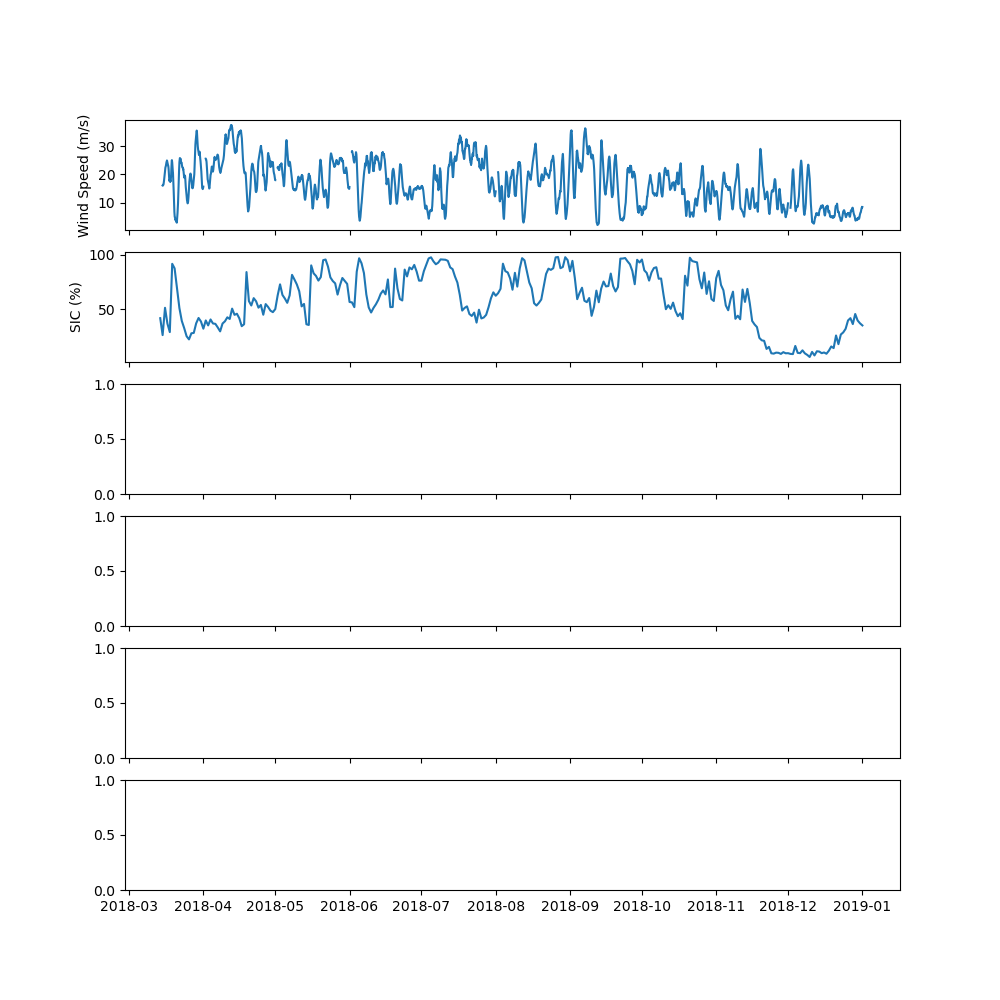

In [61]:
# define rolling average 
rolling = 96 # daily 
# plot timeseries of along trough velocity, wind speed, salinity, temperature, density, SIC 
fig, ax = plt.subplots(nrows=6,ncols=1,figsize=(10,10),sharex=True)

# WIND SPEED 
ax[0].plot(wspd_15.rolling(time=rolling).mean().time,wspd_15.rolling(time=rolling).mean().wind_speed)
ax[0].set_ylabel('Wind Speed (m/s)')
ax[0].tick_params(labelbottom=False)

# SIC 
ax[1].plot(tnb_sic_2018.time,tnb_sic_2018)
ax[1].set_ylabel('SIC (%)')

# Along Trough Velocity 
ax[2].plot(Q_DITD_along.rolling(time=rolling).mean().time,Q_DITD_along.rolling(time=rolling).mean()*1e-6)
ax[2].axhline(y=0, color="k", linestyle="--", linewidth=2)
ax[2].set_ylabel('Along-Trough \n Transport (Sv)')
ax[2].tick_params(labelbottom=False)

# Absolute Salinity 
ax[3].plot(DITD_ctd.rolling(time=rolling).mean().time,DITD_ctd.rolling(time=rolling).mean().abs_sal)
ax[3].set_ylabel('Absolute \n Salinity (g/kg)')
ax[3].tick_params(labelbottom=False)

# Potential Temp 
ax[4].plot(DITD_ctd.rolling(time=rolling).mean().time,DITD_ctd.rolling(time=rolling).mean().theta)
ax[4].set_ylabel('Potential \n Temp (Deg C)')
ax[4].tick_params(labelbottom=False)

# potential density anomaly 
ax[5].plot(DITD_ctd.rolling(time=rolling).mean().time,DITD_ctd.rolling(time=rolling).mean().sigma0)
ax[5].set_ylabel('Potential Density \n Anomaly (kg/m3)')

# Loop through each axes object to enable vertical grids
for axs in ax:
    # axs.plot([1, 2, 3], [4, 5, 6])
    axs.grid(True, axis='both', color='gray', linestyle='--', linewidth=0.5)

# plt.suptitle('TNBD')

### TO DO: 

1. Compare volume transport estimates with literature to see if values are reasonable 

2. Correctly calculate polynya area (see Miller et al. 2024 for methods)

3. Look into estimating salt and heat transports - first look at literature to understand why we use these values and what reference values should be used 

4. Get estimates on different timescales (i.e. monthly, seasonal, weekly, daily)

5. Estimate volume, heat, and salt transport for historical D and DITD 

### July Freshening Event 

In [62]:
TNBD_vel

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 28224)
Coordinates:
  * time     (time) datetime64[ns] 226kB 2018-03-14 ... 2019-01-01T23:45:00
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...
Data variables:
    u        (time) float64 226kB 0.01884 0.02529 0.0318 ... 0.03174 0.02243
    v        (time) float64 226kB -0.01053 -0.01238 ... -0.01423 0.005191
    w        (time) float64 226kB -0.022 0.003 0.005 ... 0.013 0.011 0.026
    pres     (time) float64 226kB 1.154e+03 1.154e+03 ... 1.153e+03 1.153e+03
    speed    (time) float64 226kB 2.2 2.9 3.6 2.8 3.1 ... 4.7 4.9 3.7 3.5 2.3
    dir      (time) float64 226kB 346.6 343.5 343.6 28.44 ... 294.4 341.6 304.4
    u_prime  (time) float64 226kB 0.02149 0.02785 0.03506 ... 0.03421 0.01552
    v_prime  (time) float64 226kB 0.002022 0.004155 0.005159 ... 0.006289 0.017

Text(0.5, 0.98, 'DITD')

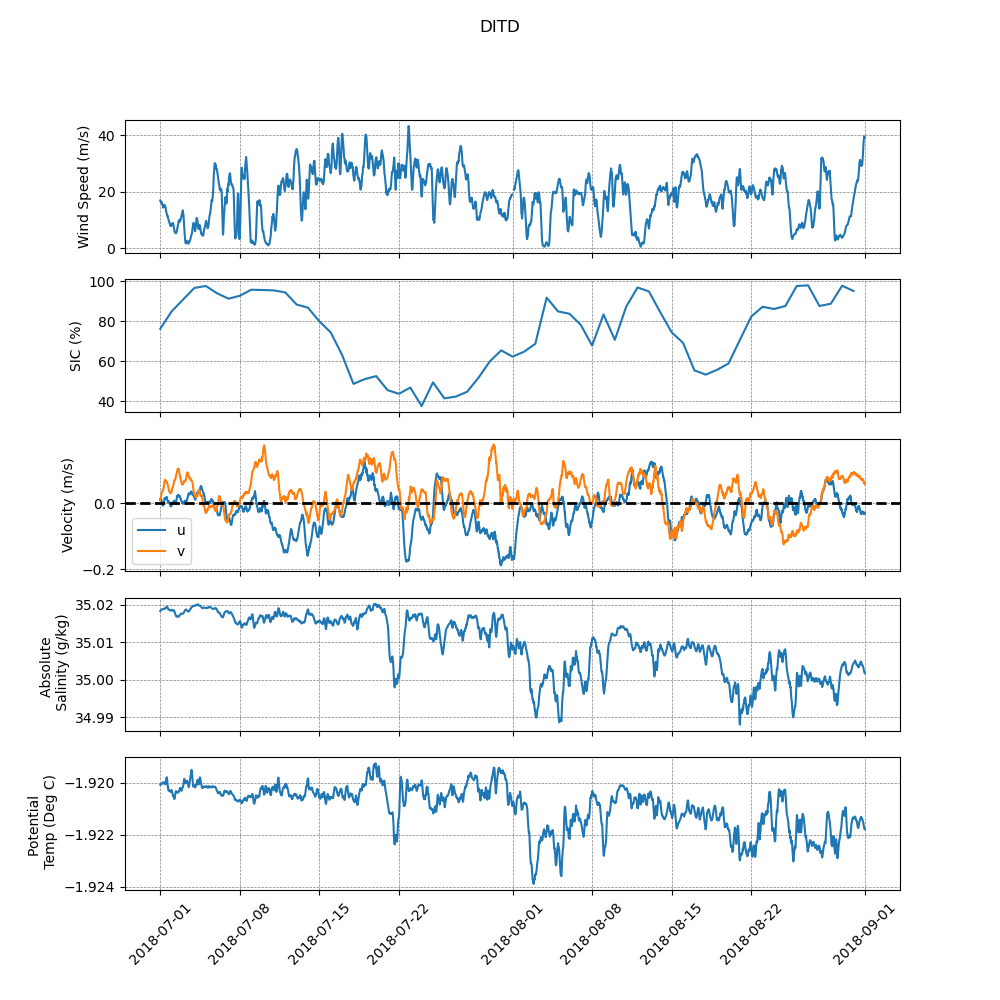

In [110]:
# define rolling average 
rolling = 12 # daily 
time_slice = slice('2018-07','2018-08')
# plot timeseries of along trough velocity, wind speed, salinity, temperature, density, SIC 
fig, ax = plt.subplots(nrows=5,ncols=1,figsize=(10,10),sharex=True)

# WIND SPEED 
ax[0].plot(wspd_15.rolling(time=rolling).mean().sel(time=time_slice).time,wspd_15.rolling(time=rolling).mean().sel(time=time_slice).wind_speed)
ax[0].set_ylabel('Wind Speed (m/s)')
ax[0].tick_params(labelbottom=False)

# SIC 
ax[1].plot(tnb_sic_2018.sel(time=time_slice).time,tnb_sic_2018.sel(time=time_slice))
ax[1].set_ylabel('SIC (%)')

# Transport
ax[2].plot(DITD_vel.rolling(time=rolling).mean().sel(time=time_slice).time,DITD_vel.rolling(time=rolling).mean().sel(time=time_slice).u,label='u')
ax[2].plot(DITD_vel.rolling(time=rolling).mean().sel(time=time_slice).time,DITD_vel.rolling(time=rolling).mean().sel(time=time_slice).v,label='v')
ax[2].legend()
ax[2].axhline(y=0, color="k", linestyle="--", linewidth=2)
ax[2].set_ylabel('Velocity (m/s)')
ax[2].tick_params(labelbottom=False)

# Absolute Salinity 
ax[3].plot(DITD_ctd.rolling(time=rolling).mean().sel(time=time_slice).time,DITD_ctd.rolling(time=rolling).mean().sel(time=time_slice).abs_sal)
ax[3].set_ylabel('Absolute \n Salinity (g/kg)')
ax[3].tick_params(labelbottom=False)

# Potential Temp 
ax[4].plot(DITD_ctd.rolling(time=rolling).mean().sel(time=time_slice).time,DITD_ctd.rolling(time=rolling).mean().sel(time=time_slice).theta)
ax[4].set_ylabel('Potential \n Temp (Deg C)')
ax[4].tick_params(axis='x', labelrotation=45)

# potential density anomaly 
# ax[5].plot(DITD_ctd.rolling(time=rolling).mean().sel(time=time_slice).time,DITD_ctd.rolling(time=rolling).mean().sel(time=time_slice).sigma0)
# ax[5].set_ylabel('Potential Density \n Anomaly (kg/m3)')

# Loop through each axes object to enable vertical grids
for axs in ax:
    # axs.plot([1, 2, 3], [4, 5, 6])
    axs.grid(True, axis='both', color='gray', linestyle='--', linewidth=0.5)

plt.suptitle('DITD')

In [120]:
# Set base size for everything
plt.rcParams['font.size'] = 14  

# Scale individual components explicitly
plt.rcParams['axes.titlesize'] = 18     # Title size
plt.rcParams['axes.labelsize'] = 12     # X and Y axis labels
plt.rcParams['xtick.labelsize'] = 12    # X-axis tick numbers
plt.rcParams['ytick.labelsize'] = 12    # Y-axis tick numbers
plt.rcParams['legend.fontsize'] = 12    # Legend content
plt.rcParams['figure.titlesize'] = 22   # Overall figure suptitle

In [131]:
TNBD_vel

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 28224)
Coordinates:
  * time     (time) datetime64[ns] 226kB 2018-03-14 ... 2019-01-01T23:45:00
    lat      float64 8B ...
    lon      float64 8B ...
    z        int64 8B ...
Data variables:
    u        (time) float64 226kB 0.01884 0.02529 0.0318 ... 0.03174 0.02243
    v        (time) float64 226kB -0.01053 -0.01238 ... -0.01423 0.005191
    w        (time) float64 226kB -0.022 0.003 0.005 ... 0.013 0.011 0.026
    pres     (time) float64 226kB 1.154e+03 1.154e+03 ... 1.153e+03 1.153e+03
    speed    (time) float64 226kB 2.2 2.9 3.6 2.8 3.1 ... 4.7 4.9 3.7 3.5 2.3
    dir      (time) float64 226kB 346.6 343.5 343.6 28.44 ... 294.4 341.6 304.4
    u_prime  (time) float64 226kB 0.02149 0.02785 0.03506 ... 0.03421 0.01552
    v_prime  (time) float64 226kB 0.002022 0.004155 0.005159 ... 0.006289 0.017

Text(0.5, 0.98, 'TNBD')

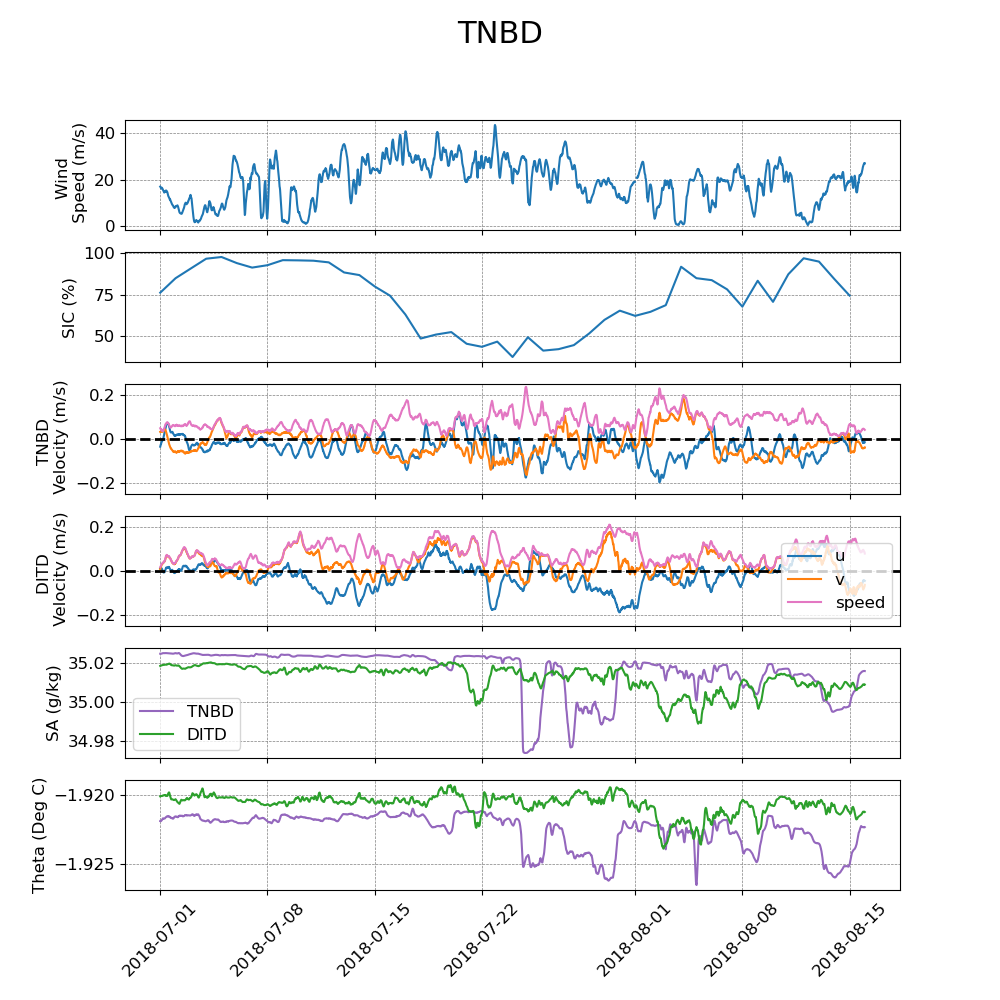

In [132]:
# define rolling average 
rolling = 12 # daily 
time_slice = slice('2018-07','2018-08-15')
# plot timeseries of along trough velocity, wind speed, salinity, temperature, density, SIC 
fig, ax = plt.subplots(nrows=6,ncols=1,figsize=(10,10),sharex=True)

# WIND SPEED 
ax[0].plot(wspd_15.rolling(time=rolling).mean().sel(time=time_slice).time,wspd_15.rolling(time=rolling).mean().sel(time=time_slice).wind_speed)
ax[0].set_ylabel('Wind \n Speed (m/s)')
ax[0].tick_params(labelbottom=False)

# SIC 
ax[1].plot(tnb_sic_2018.sel(time=time_slice).time,tnb_sic_2018.sel(time=time_slice))
ax[1].set_ylabel('SIC (%)')

# Transport
ax[2].plot(TNBD_vel.rolling(time=rolling).mean().sel(time=time_slice).time,TNBD_vel.rolling(time=rolling).mean().sel(time=time_slice).u,label='u')
ax[2].plot(TNBD_vel.rolling(time=rolling).mean().sel(time=time_slice).time,TNBD_vel.rolling(time=rolling).mean().sel(time=time_slice).v,label='v')
ax[2].plot(TNBD_vel.rolling(time=rolling).mean().sel(time=time_slice).time,TNBD_vel.rolling(time=rolling).mean().sel(time=time_slice).speed/100,label='speed',color='tab:pink')
# ax[2].legend()
ax[2].axhline(y=0, color="k", linestyle="--", linewidth=2)
ax[2].set_ylabel('TNBD \n Velocity (m/s)')
ax[2].tick_params(labelbottom=False)
ax[2].set_ylim(-0.25,0.25)

ax[3].plot(DITD_vel.rolling(time=rolling).mean().sel(time=time_slice).time,DITD_vel.rolling(time=rolling).mean().sel(time=time_slice).u,label='u')
ax[3].plot(DITD_vel.rolling(time=rolling).mean().sel(time=time_slice).time,DITD_vel.rolling(time=rolling).mean().sel(time=time_slice).v,label='v')
ax[3].plot(DITD_vel.rolling(time=rolling).mean().sel(time=time_slice).time,DITD_vel.rolling(time=rolling).mean().sel(time=time_slice).speed,label='speed',color='tab:pink')
ax[3].legend()
ax[3].axhline(y=0, color="k", linestyle="--", linewidth=2)
ax[3].set_ylabel('DITD \n Velocity (m/s)')
ax[3].tick_params(labelbottom=False)
ax[3].set_ylim(-0.25,0.25)

# Absolute Salinity 
ax[4].plot(TNBD_ctd.rolling(time=rolling).mean().sel(time=time_slice).time,TNBD_ctd.rolling(time=rolling).mean().sel(time=time_slice).abs_sal,color='tab:purple',label='TNBD')
ax[4].plot(DITD_ctd.rolling(time=rolling).mean().sel(time=time_slice).time,DITD_ctd.rolling(time=rolling).mean().sel(time=time_slice).abs_sal, color='tab:green',label='DITD')
ax[4].set_ylabel('SA (g/kg)')
ax[4].tick_params(labelbottom=False)
ax[4].legend()

# Potential Temp 
ax[5].plot(TNBD_ctd.rolling(time=rolling).mean().sel(time=time_slice).time,TNBD_ctd.rolling(time=rolling).mean().sel(time=time_slice).theta,color='tab:purple',label='TNBD')
ax[5].plot(DITD_ctd.rolling(time=rolling).mean().sel(time=time_slice).time,DITD_ctd.rolling(time=rolling).mean().sel(time=time_slice).theta, color='tab:green',label='DITD')
ax[5].set_ylabel('Theta (Deg C)')
ax[5].tick_params(axis='x', labelrotation=45)

# potential density anomaly 
# ax[5].plot(TNBD_ctd.rolling(time=rolling).mean().sel(time=time_slice).time,TNBD_ctd.rolling(time=rolling).mean().sel(time=time_slice).sigma0)
# ax[5].set_ylabel('Potential Density \n Anomaly (kg/m3)')

# Loop through each axes object to enable vertical grids
for axs in ax:
    # axs.plot([1, 2, 3], [4, 5, 6])
    axs.grid(True, axis='both', color='gray', linestyle='--', linewidth=0.5)

plt.suptitle('TNBD')

In [136]:
DITD_ctd.lat

<xarray.DataArray 'lat' ()> Size: 8B
array(-75.28)
Coordinates:
    lat      float64 8B -75.28
    lon      float64 8B 164.1
    z        int64 8B 1121

In [96]:
D_ctd_mid

<xarray.Dataset> Size: 1MB
Dimensions:       (time: 14736)
Coordinates:
  * time          (time) datetime64[ns] 118kB 2018-03-01T00:25:00 ... 2019-01...
    z             float64 8B ...
    lat           float64 8B ...
    lon           float64 8B ...
Data variables:
    T_0           (time) float64 118kB ...
    S_0           (time) float64 118kB ...
    Conductivity  (time) float64 118kB ...
    Theta_0       (time) float64 118kB ...
    Density       (time) float64 118kB ...
    S_2           (time) float64 118kB ...
    T_2           (time) float64 118kB ...
    sal           (time) float64 118kB ...
    temp          (time) float64 118kB ...
Attributes: (12/14)
    cruise_deployment:               PNRA - XXXII Expedition - 2016/17  
    cruise_recovery:                 PNRA - XXXIV Expedition - 2019/20
    water_depth_meters:              -1144
    instr_depth_meters:              -772
    instr_type:                      SBE 37
    instr_sn:                        15451
    ...                              ...
    samp_int_minutes:                30
    start_time:                      11/02/2017 07:25:00
    stop_time:                       18/02/2019 23:25:00
    level_0:                         Raw data
    level_1:                         Despiking
    level_2:                         CTD quality check

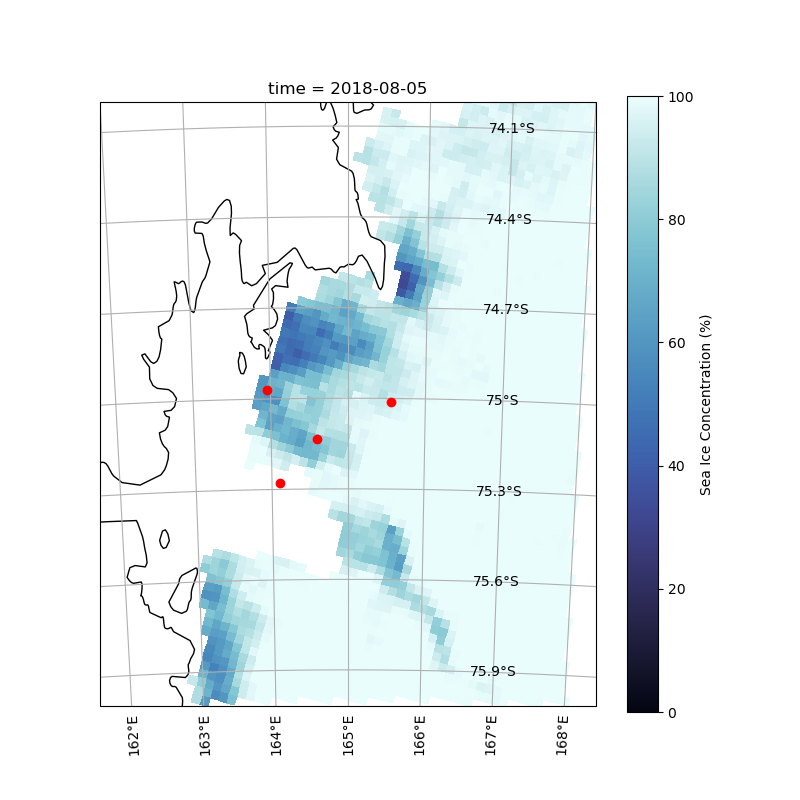

In [106]:
fig = plt.figure(figsize=(8,8))

ax = plt.axes(
    projection=ccrs.SouthPolarStereo(
        central_longitude=165
    )
)

ax.coastlines()
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False

tnb.sic.sel(time='2018-08-05').plot(
    ax=ax,
    x="lon",
    y="lat",
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.ice,
    vmin=0,
    vmax=100,
    cbar_kwargs={'label': 'Sea Ice Concentration (%)'}
)

ax.set_extent(
    [162,168,-76,-74],
    crs=ccrs.PlateCarree()
)

ax.scatter(TNBD_ctd.lon,TNBD_ctd.lat,transform=ccrs.PlateCarree(),color='r',zorder=10)
ax.scatter(DITD_ctd.lon,DITD_ctd.lat,transform=ccrs.PlateCarree(),color='r',zorder=10)
ax.scatter(D_ctd_mid.lon,D_ctd_mid.lat,transform=ccrs.PlateCarree(),color='r',zorder=10)
ax.scatter(163.96,-74.97,transform=ccrs.PlateCarree(),color='r',zorder=10)



plt.show()